In [1]:
# DASK client set

import os
import sys
from dask.distributed import Client
# client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler.json', threads_per_worker=2, n_workers=6)
client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler.json')
# client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler_10.json')  

# add private module path for workers
# client.run(lambda: os.environ.update({'PYTHONPATH': '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2'}))
# def add_path():
#     if '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2' not in sys.path:
#         sys.path.append('/proj/kimyy/Dropbox/source/python/all/Modules/CESM2')

# client.run(add_path)

def setup_module_path():
    module_path = '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2'
    if module_path not in sys.path:
        sys.path.append(module_path)

client.run(setup_module_path)

client

# get path for path changes in Jupyter notebook: File - Open from Path - insert relative_path
notebook_path = os.path.abspath(".")
_, _, relative_path = notebook_path.partition('/all/')
relative_path = '/all/' + relative_path
relative_path

'/all/Model/CESM2/Earth_System_Predictability/DIC'

# Load modules

In [2]:
# load public modules

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.ticker as mticker
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from scipy.interpolate import griddata
import cmocean
from cmcrameri import cm
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
import cftime
import pop_tools
from pprint import pprint
import time
import subprocess
import re as re_mod
import cftime
import datetime
from scipy.stats import ttest_1samp


In [3]:
import xcesm
import gsw

In [4]:
# load private modules

import sys
sys.path.append('/proj/kimyy/Dropbox/source/python/all/Modules/CESM2')
from KYY_CESM2_NWP_preprocessing import CESM2_NWP_config
# import KYY_CESM2_preprocessing
# import importlib
# importlib.reload(KYY_CESM2_preprocessing)

# Variable configuration

In [5]:
# # 1. DIC (Total)
# cfg_var_DIC=CESM2_NWP_config()
# cfg_var_DIC.year_s=1955
# cfg_var_DIC.year_e=2020
# cfg_var_DIC.setvar('DIC')

# # 2. TEMP (Total)
# cfg_var_TEMP=CESM2_NWP_config()
# cfg_var_TEMP.year_s=1955
# cfg_var_TEMP.year_e=2020
# cfg_var_TEMP.setvar('TEMP')

# # 3. SALT (Total)
# cfg_var_SALT=CESM2_NWP_config()
# cfg_var_SALT.year_s=1955
# cfg_var_SALT.year_e=2020
# cfg_var_SALT.setvar('SALT')
cfgs = {}
varlist = ["DIC", "TEMP", "SALT", "FG_CO2", "DIC_ALT_CO2"]
for varname in varlist:
    cfg = CESM2_NWP_config()
    cfg.year_s = 1954
    cfg.year_e = 2020
    cfg.setvar(varname)
    cfgs[varname] = cfg

if cfgs[varname].comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

# Read dataset (functions)

In [6]:
# define preprocessing function

# exceptcv=['time','lon','lat','lev', 'TAREA', 'TLONG', 'TLAT', 'z_t', 'z_t_2', cfg_var_DIC.var, cfg_var_TEMP.var]
# exceptcv=['time','lon','lat','lev', 'TAREA', 'TLONG', 'TLAT', 'z_t', 'dz', 'z_t_2', cfg_var_DIC.var, cfg_var_TEMP.var]


# exceptcv = [
#     'time', 'lon', 'lat', 'lev', 'TAREA', 'TLONG', 'TLAT', 'z_w', 'z_w_top', 'z_t', 'ULONG', 'ULAT', 'VLONG', 'VLAT'
# ] + [cfg.var for cfg in cfgs.values()]
exceptcv = [
    'time', 'lon', 'lat', 'lev', 'TAREA', 'TLONG', 'TLAT', 'z_t', 'MTD'
] + [cfg.var for cfg in cfgs.values()]



def process_coords_3d(ds, sd, ed, drop=True, except_coord_vars=exceptcv):
    """Preprocessor function to drop all non-dim coords, which slows down concatenation."""
    coord_vars = []
    for v in np.array(ds.coords) :
        if not v in except_coord_vars:
            coord_vars += [v]
    for v in np.array(ds.data_vars) :
        if not v in except_coord_vars:
            coord_vars += [v]

    if drop:
        ds= ds.drop(coord_vars)
        ds= ds.sel(time=slice(sd, ed))
        # ds = ds.isel(z_t=slice(0, 39)) # ~39 layer (1000m)
        # ds = (ds.isel(z_t=slice(1, 39)) * ds.dz).sum(dim='z_t') / ds.dz.sum(dim='z_t')
        return ds
    else:
        return ds.set_coords(coord_vars)



def process_coords_3d_LE(ds, sd, ed, drop=True, except_coord_vars=exceptcv):
    """
    Preprocessor function for CESM POP-style datasets.
    - Normalizes vertical coordinate: if z_t or z_t_2 exists, rename to 'depth'.
    - Replaces its values with z_t_new for consistency.
    - Optionally drops unnecessary coordinate variables for faster concatenation.
    """
    z_t_new = np.array([5.0000000e+00, 1.5000000e+01, 2.5000000e+01, 3.5000000e+01,
       4.5000000e+01, 5.5000000e+01, 6.5000000e+01, 7.5000000e+01,
       8.5000000e+01, 9.5000000e+01, 1.0500000e+02, 1.1500000e+02,
       1.2500000e+02, 1.3500000e+02, 1.4500000e+02, 1.5500000e+02,
       1.6509839e+02, 1.7547903e+02, 1.8629126e+02, 1.9766026e+02,
       2.0971138e+02, 2.2257828e+02, 2.3640883e+02, 2.5137015e+02,
       2.6765421e+02, 2.8548364e+02, 3.0511920e+02, 3.2686798e+02,
       3.5109348e+02, 3.7822760e+02, 4.0878464e+02, 4.4337769e+02,
       4.8273669e+02, 5.2772797e+02, 5.7937286e+02, 6.3886261e+02,
       7.0756329e+02, 7.8700250e+02, 8.7882520e+02, 9.8470581e+02,
       1.1062042e+03, 1.2445669e+03, 1.4004972e+03, 1.5739464e+03,
       1.7640033e+03, 1.9689442e+03, 2.1864565e+03, 2.4139714e+03,
       2.6490012e+03, 2.8893845e+03, 3.1334045e+03, 3.3797935e+03,
       3.6276702e+03, 3.8764519e+03, 4.1257681e+03, 4.3753926e+03,
       4.6251904e+03, 4.8750835e+03, 5.1250278e+03, 5.3750000e+03])
    
    # ------------------------------------------------------
    # 1️⃣ Normalize vertical coordinate name
    # ------------------------------------------------------
    if "z_t_2" in ds.dims:
        ds = ds.rename({"z_t_2": "depth"})
    elif "z_t" in ds.dims:
        ds = ds.rename({"z_t": "depth"})
    else:
        print("[Warning] No vertical coordinate (z_t or z_t_2) found — skipped.")
        return ds

    # Drop any leftover z_t/z_t_2 coordinate variable if it exists
    ds = ds.drop_vars(["z_t", "z_t_2"], errors="ignore")

    # ------------------------------------------------------
    # 2️⃣ Replace coordinate values with z_t_new
    # ------------------------------------------------------
    if "depth" in ds.coords:
        if len(ds["depth"]) == len(z_t_new):
            ds = ds.assign_coords(depth=z_t_new)
        else:
            print(f"[Warning] depth length mismatch: {len(ds['depth'])} vs {len(z_t_new)}")
    else:
        print("[Warning] depth coordinate missing after renaming.")

    # ------------------------------------------------------
    # 3️⃣ Clean up coordinate references inside variable attributes
    # ------------------------------------------------------
    for v in ds.data_vars:
        if "coordinates" in ds[v].attrs:
            ds[v].attrs["coordinates"] = (
                ds[v].attrs["coordinates"]
                .replace("z_t_2", "depth")
                .replace("z_t", "depth")
            )

    # ------------------------------------------------------
    # 4️⃣ Drop unnecessary coordinate variables and slice time
    # ------------------------------------------------------
    coord_vars = []
    for v in np.array(ds.coords):
        if v not in except_coord_vars:
            coord_vars.append(v)
    for v in np.array(ds.data_vars):
        if v not in except_coord_vars:
            coord_vars.append(v)

    if drop:
        ds = ds.drop(coord_vars, errors="ignore")
        ds = ds.sel(time=slice(sd, ed))
    else:
        ds = ds.set_coords(coord_vars)

    return ds

start_date = cftime.DatetimeNoLeap(cfgs[varname].year_s, 2, 1)
end_date = cftime.DatetimeNoLeap(cfgs[varname].year_e+1, 1, 1)


# ds = ds.isel(lev=slice(1, 11))

In [7]:
lat_range = slice(10, 60)
lon_range = slice(110, 190)

# read dataset (regridded variables)

In [8]:
# get ODA regridded file list

import os
import glob

BASE_RGD = "/mnt/lustre/proj/kimyy/tr_sysong/fld/regridded/ODA/NWP/ocn"

vars = varlist
file_list_assm = {}

for var in vars:
    print(f"\n===== Collecting regridded files for {var} =====")

    var_dir = os.path.join(BASE_RGD, var)

    if not os.path.isdir(var_dir):
        print(f"Directory not found: {var_dir}")
        continue

    # Detect ensemble directories automatically
    ens_dirs = sorted(
        [
            d for d in os.listdir(var_dir)
            if os.path.isdir(os.path.join(var_dir, d))
        ]
    )

    print(f"Detected ensembles: {ens_dirs}")

    rgd_file_list = []

    for ens in ens_dirs:
        ens_path = os.path.join(var_dir, ens)

        # Collect all regridded files regardless of time segmentation
        files = sorted(
            glob.glob(os.path.join(ens_path, "regridded_*.nc"))
        )

        # print(f"\n--- Ensemble {ens} ---")
        # print(f"Number of files: {len(files)}")

        # for f in files:
        #     print(f)

        rgd_file_list.append(files)

    file_list_assm[var] = rgd_file_list


===== Collecting regridded files for DIC =====
Detected ensembles: ['en4.2_ba-10p1', 'en4.2_ba-10p2', 'en4.2_ba-10p3', 'en4.2_ba-10p4', 'en4.2_ba-10p5', 'en4.2_ba-20p1', 'en4.2_ba-20p2', 'en4.2_ba-20p3', 'en4.2_ba-20p4', 'en4.2_ba-20p5', 'projdv7.3_ba-10p1', 'projdv7.3_ba-10p2', 'projdv7.3_ba-10p3', 'projdv7.3_ba-10p4', 'projdv7.3_ba-10p5', 'projdv7.3_ba-20p1', 'projdv7.3_ba-20p2', 'projdv7.3_ba-20p3', 'projdv7.3_ba-20p4', 'projdv7.3_ba-20p5']

===== Collecting regridded files for TEMP =====
Detected ensembles: ['en4.2_ba-10p1', 'en4.2_ba-10p2', 'en4.2_ba-10p3', 'en4.2_ba-10p4', 'en4.2_ba-10p5', 'en4.2_ba-20p1', 'en4.2_ba-20p2', 'en4.2_ba-20p3', 'en4.2_ba-20p4', 'en4.2_ba-20p5', 'projdv7.3_ba-10p1', 'projdv7.3_ba-10p2', 'projdv7.3_ba-10p3', 'projdv7.3_ba-10p4', 'projdv7.3_ba-10p5', 'projdv7.3_ba-20p1', 'projdv7.3_ba-20p2', 'projdv7.3_ba-20p3', 'projdv7.3_ba-20p4', 'projdv7.3_ba-20p5']

===== Collecting regridded files for SALT =====
Detected ensembles: ['en4.2_ba-10p1', 'en4.2_ba-10p2

In [9]:
# get ODA regridded file list (MTD only)

BASE_RGD = "/mnt/lustre/proj/kimyy/tr_sysong/fld/regridded/ODA/NWP/ocn"

var = 'MTD'
print(f"\n===== Collecting regridded files for {var} =====")

var_dir = os.path.join(BASE_RGD, var)

# Detect ensemble directories automatically
ens_dirs = sorted(
    [
        d for d in os.listdir(var_dir)
        if os.path.isdir(os.path.join(var_dir, d))
    ]
)

print(f"Detected ensembles: {ens_dirs}")

rgd_file_list = []

for ens in ens_dirs:
    ens_path = os.path.join(var_dir, ens)

    # Collect all regridded files regardless of time segmentation
    files = sorted(
        glob.glob(os.path.join(ens_path, "regridded_*.nc"))
    )
    rgd_file_list.append(files)

file_list_assm[var] = rgd_file_list


===== Collecting regridded files for MTD =====
Detected ensembles: ['en4.2_ba-10p1', 'en4.2_ba-10p2', 'en4.2_ba-10p3', 'en4.2_ba-10p4', 'en4.2_ba-10p5', 'en4.2_ba-20p1', 'en4.2_ba-20p2', 'en4.2_ba-20p3', 'en4.2_ba-20p4', 'en4.2_ba-20p5', 'projdv7.3_ba-10p1', 'projdv7.3_ba-10p2', 'projdv7.3_ba-10p3', 'projdv7.3_ba-10p4', 'projdv7.3_ba-10p5', 'projdv7.3_ba-20p1', 'projdv7.3_ba-20p2', 'projdv7.3_ba-20p3', 'projdv7.3_ba-20p4', 'projdv7.3_ba-20p5']


In [10]:
# get WDA regridded file list (MTD only)

import os
import glob

BASE_RGD = "/mnt/lustre/proj/kimyy/tr_sysong/fld/regridded/WDA/NWP/ocn"

var = "MTD"

print(f"\n===== Collecting WDA regridded files for {var} =====")

var_dir = os.path.join(BASE_RGD, var)

if not os.path.isdir(var_dir):
    raise FileNotFoundError(f"WDA directory not found: {var_dir}")

# WDA: ens 폴더 없음 → 바로 파일 수집
files = sorted(
    glob.glob(os.path.join(var_dir, "regridded_*.nc"))
)

print(f"WDA files found: {len(files)}")

# ODA와 동일 인터페이스 유지 (list of list)
file_list_WDA = {}
file_list_WDA[var] = [files]



===== Collecting WDA regridded files for MTD =====
WDA files found: 14


In [11]:
# get LE regridded file list

import os
import glob
import re
from collections import defaultdict

BASE_RGD = "/mnt/lustre/proj/kimyy/tr_sysong/fld/regridded/LENS2/NWP/ocn"

vars = varlist
file_list_le = {}

for var in vars:
    print(f"\n===== Collecting regridded files for {var} =====")

    var_dir = os.path.join(BASE_RGD, var)

    if not os.path.isdir(var_dir):
        print(f"Directory not found: {var_dir}")
        continue

    ens_dirs = [
        d for d in os.listdir(var_dir)
        if os.path.isdir(os.path.join(var_dir, d))
    ]

    # Group by LE member ID (LE2-xxxx.xxx)
    grouped = defaultdict(list)

    for ens_dir in ens_dirs:
        match = re.search(r"(LE2-[0-9]+\.[0-9]+)", ens_dir)
        if match:
            member_id = match.group(1)
            full_path = os.path.join(var_dir, ens_dir)

            files = glob.glob(
                os.path.join(full_path, "regridded_*.nc")
            )

            grouped[member_id].extend(files)

    # Sort each member's files
    final_file_list = []

    for member in sorted(grouped.keys()):
        files_sorted = sorted(grouped[member])
        # print(f"\n--- Member {member} ---")
        # print(f"Number of files: {len(files_sorted)}")
        # for f in files_sorted:
        #     print(f)

        final_file_list.append(files_sorted)

    file_list_le[var] = final_file_list



===== Collecting regridded files for DIC =====

===== Collecting regridded files for TEMP =====

===== Collecting regridded files for SALT =====

===== Collecting regridded files for FG_CO2 =====

===== Collecting regridded files for DIC_ALT_CO2 =====


In [12]:
# read regridded files

vars = varlist
results = {}

for var in vars:
    print(f"\n===== Processing {var} =====")

    cfg_var = cfgs[var]
    cfg_var.var = var

    # ================= LE =================
    t0 = time.time()
    cfg_var.LE_path_load(cfg_var.var)
    cfg_var.LE_ds_rgd = xr.open_mfdataset(
        file_list_le[var],
        chunks={'time': 12},
        combine='nested',
        concat_dim=[[*cfg_var.LE_ensembles], 'time'],
        parallel=True,
        preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
        decode_cf=True,
        decode_times=True,
    )
    cfg_var.LE_ds_rgd = cfg_var.LE_ds_rgd.rename({"concat_dim": "ens_LE"})
    cfg_var.LE_ds_rgd = cfg_var.LE_ds_rgd.sortby("time")
    print(f"  LE read: {time.time() - t0:.1f} s")


    # ================= WDA =================
    t0 = time.time()
    cfg_var.WDA_path_load(cfg_var.var)
    cfg_var.WDA_ds = xr.open_mfdataset(
        cfg_var.WDA_file_list[0],
        chunks={'time': 12},
        combine='nested',
        concat_dim=[[*cfg_var.WDA_ensembles], 'time'],
        parallel=True,
        preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
        decode_cf=True,
        decode_times=True,
    )
    cfg_var.WDA_ds = cfg_var.WDA_ds.rename({"concat_dim": "ens_WDA"})
    new_time = cfg_var.WDA_ds.time - np.array(
        [datetime.timedelta(days=15)] * len(cfg_var.WDA_ds.time)
    )
    cfg_var.WDA_ds = cfg_var.WDA_ds.assign_coords(time=new_time)
    print(f"  WDA read: {time.time() - t0:.1f} s")

    # ================= ODA =================
    t0 = time.time()
    cfg_var.ODA_path_load(cfg_var.var)
    cfg_var.ODA_ds_rgd = xr.open_mfdataset(
        file_list_assm[var][10:20],
        chunks={'time': 12},
        combine='nested',
        concat_dim=[[*cfg_var.ODA_ensembles][10:20], 'time'],
        parallel=True,
        preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
        decode_cf=True,
        decode_times=True,
    )
    cfg_var.ODA_ds_rgd = cfg_var.ODA_ds_rgd.rename({"concat_dim": "ens_ODA"})
    cfg_var.ODA_ds_rgd = cfg_var.ODA_ds_rgd.sortby("time")
    print(f"  ODA read: {time.time() - t0:.1f} s")

    
    cfg_var.WDA_ds_rgd = (
        cfg_var.WDA_ds[var]
        .isel(ens_WDA=0)
        .utils.regrid()
        .sel(lat=lat_range, lon=lon_range)
        .sortby("time")
    )
    print(f"  REGRID WDA: {time.time() - t0:.1f} s")

    if "z_t" in cfg_var.LE_ds_rgd.dims and "z_t" in cfg_var.ODA_ds_rgd.coords:
        cfg_var.LE_ds_rgd = cfg_var.LE_ds_rgd.assign_coords(
            z_t=cfg_var.ODA_ds_rgd.z_t
        )
    

    results[var] = cfg_var



===== Processing DIC =====
  LE read: 6.4 s
  WDA read: 1.8 s
  ODA read: 2.7 s
  REGRID WDA: 57.6 s

===== Processing TEMP =====
  LE read: 4.7 s
  WDA read: 1.7 s
  ODA read: 3.1 s
  REGRID WDA: 58.2 s

===== Processing SALT =====
  LE read: 5.1 s
  WDA read: 1.8 s
  ODA read: 2.7 s
  REGRID WDA: 58.3 s

===== Processing FG_CO2 =====
  LE read: 4.3 s
  WDA read: 1.6 s
  ODA read: 2.4 s
  REGRID WDA: 3.5 s

===== Processing DIC_ALT_CO2 =====
  LE read: 4.5 s
  WDA read: 1.8 s
  ODA read: 3.7 s
  REGRID WDA: 59.3 s


In [13]:
# read ODA regridded files (MTD)

var = 'MTD'

cfg = CESM2_NWP_config()
cfg.year_s = 1954
cfg.year_e = 2020
# cfg.setvar(var)
cfgs[var] = cfg

print(f"\n===== Processing {var} =====")

cfg_var = cfgs[var]
cfg_var.var = var

# ================= ODA =================
t0 = time.time()
cfg_var.ODA_ds_rgd = xr.open_mfdataset(
    file_list_assm[var][10:20],
    chunks={'time': 12},
    combine='nested',
    concat_dim=[[*cfgs['TEMP'].ODA_ensembles][10:20], 'time'],
    parallel=True,
    preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
    decode_cf=True,
    decode_times=True,
)
cfg_var.ODA_ds_rgd = cfg_var.ODA_ds_rgd.rename({"concat_dim": "ens_ODA"})
cfg_var.ODA_ds_rgd = cfg_var.ODA_ds_rgd.sortby("time")
print(f"  ODA read: {time.time() - t0:.1f} s")

results[var] = cfg_var



===== Processing MTD =====
  ODA read: 4.5 s


In [14]:
# read WDA regridded files (MTD)

# ================= WDA MTD =================
import time

t0 = time.time()

cfg_var.WDA_ds_rgd = xr.open_mfdataset(
    file_list_WDA[var][0],   # ← 핵심 수정
    chunks={'time': 12},
    combine='nested',
    concat_dim='time',
    parallel=True,
    preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
    decode_cf=True,
    decode_times=True,
)

cfg_var.WDA_ds_rgd = cfg_var.WDA_ds_rgd.sortby("time")

print(f"  WDA read: {time.time() - t0:.1f} s")


  WDA read: 0.2 s


In [15]:
# make nDIC

results["nDIC"] = CESM2_NWP_config()

for key in ["ODA", "LE", "WDA"]:

    dic_obj  = getattr(results["DIC"],  f"{key}_ds_rgd")
    salt_obj = getattr(results["SALT"], f"{key}_ds_rgd")

    # get DataArrays
    dic_da  = dic_obj["DIC"]  if isinstance(dic_obj,  xr.Dataset) else dic_obj
    salt_da = salt_obj["SALT"] if isinstance(salt_obj, xr.Dataset) else salt_obj

    dic_da, salt_da = xr.align(dic_da, salt_da, join="inner")

    ndic_da = dic_da * 35.0 / salt_da
    ndic_da.name = "nDIC"
    ndic_da.attrs["long_name"] = "Salinity-normalized DIC (S=35)"
    ndic_da.attrs["units"] = dic_da.attrs.get("units","")

    setattr(results["nDIC"], f"{key}_ds_rgd", ndic_da.to_dataset())


In [16]:
# make nDIC_ALT_CO2

results["nDIC_ALT_CO2"] = CESM2_NWP_config()

for key in ["ODA", "LE", "WDA"]:

    dic_obj  = getattr(results["DIC_ALT_CO2"],  f"{key}_ds_rgd")
    salt_obj = getattr(results["SALT"], f"{key}_ds_rgd")

    # get DataArrays
    dic_da  = dic_obj["DIC_ALT_CO2"]  if isinstance(dic_obj,  xr.Dataset) else dic_obj
    salt_da = salt_obj["SALT"] if isinstance(salt_obj, xr.Dataset) else salt_obj

    dic_da, salt_da = xr.align(dic_da, salt_da, join="inner")

    ndic_da = dic_da * 35.0 / salt_da
    ndic_da.name = "nDIC_ALT_CO2"
    ndic_da.attrs["long_name"] = "Salinity-normalized DIC_ALT_CO2 (S=35)"
    ndic_da.attrs["units"] = dic_da.attrs.get("units","")

    setattr(results["nDIC_ALT_CO2"], f"{key}_ds_rgd", ndic_da.to_dataset())

In [17]:
# read MLD files

# ============================================================
# Load gridded 3D diagnostics (MLD / nDIC_INV / DIC_INV)
# ODA / LE / WDA unified loader with toggle
# ============================================================

import glob
import os
import xarray as xr

# ------------------------------------------------------------
# USER TOGGLE
# ------------------------------------------------------------
LOAD_EXP = {
    "ODA": True,
    "LE":  True,
    "WDA": True
}

# ------------------------------------------------------------
# container
# ------------------------------------------------------------
class VarContainer:
    pass


# ------------------------------------------------------------
# generic loaders
# ------------------------------------------------------------
def load_ensemble_var(root_dir, varname, exp, ens_dim="ens"):
    """
    root_dir/
        00/
            var_EXP_00_*.nc
        01/
            var_EXP_01_*.nc
        ...
    """

    print(f"===== {varname} {exp} =====")

    ens_dirs = sorted(
        [d for d in glob.glob(os.path.join(root_dir, "*"))
         if os.path.isdir(d)]
    )

    if len(ens_dirs) == 0:
        print("No ensemble directories found.")
        return None

    ds_list = []

    for ens_path in ens_dirs:
        ens = os.path.basename(ens_path)

        filelist = sorted(
            glob.glob(os.path.join(
                ens_path,
                f"{varname}_{exp}_{ens}_*.nc"
            ))
        )

        if len(filelist) == 0:
            continue

        print(f"{varname} {exp} ens {ens}: {len(filelist)} files")

        ds_ens = xr.open_mfdataset(
            filelist,
            combine="by_coords",
            parallel=True,
            chunks={"time": 12},
            decode_cf=True,
            decode_times=True,
        )

        ds_ens = ds_ens.expand_dims({ens_dim: [int(ens)]})
        ds_list.append(ds_ens)

    if len(ds_list) == 0:
        print("No files loaded.")
        return None

    ds_all = xr.concat(ds_list, dim=ens_dim)

    if varname in ds_all:
        return ds_all[varname]
    else:
        return ds_all[list(ds_all.data_vars)[0]]


def load_single_var(root_dir, varname, exp):
    """
    root_dir/
        var_EXP_*.nc
    """
    print(f"===== {varname} {exp} =====")

    filelist = sorted(
        glob.glob(os.path.join(root_dir, f"{varname}_{exp}_*.nc"))
    )

    if len(filelist) == 0:
        print("No files found.")
        return None

    print(f"{varname} {exp}: {len(filelist)} files")

    ds = xr.open_mfdataset(
        filelist,
        combine="by_coords",
        parallel=True,
        chunks={"time": 12},
        decode_cf=True,
        decode_times=True,
    )

    if varname in ds:
        return ds[varname]
    else:
        return ds[list(ds.data_vars)[0]]


# ============================================================
# LOAD MLD (ODA / LE / WDA)
# ============================================================

results["MLD"] = VarContainer()

ROOTS = {
    "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/MLD/ODA",
    "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/MLD/LE",
    "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/MLD/WDA"
}

for EXP, root in ROOTS.items():

    if not LOAD_EXP.get(EXP, False):
        continue

    if EXP in ["ODA", "LE"]:
        ds = load_ensemble_var(
            root,
            varname="MLD",
            exp=EXP,
            ens_dim=f"ens_{EXP}"
        )
    else:
        ds = load_single_var(
            root,
            varname="MLD",
            exp=EXP
        )

    setattr(results["MLD"], f"{EXP}_ds_rgd", ds)

===== MLD ODA =====
MLD ODA ens 10: 66 files
MLD ODA ens 11: 66 files
MLD ODA ens 12: 66 files
MLD ODA ens 13: 66 files
MLD ODA ens 14: 66 files
MLD ODA ens 15: 66 files
MLD ODA ens 16: 66 files
MLD ODA ens 17: 66 files
MLD ODA ens 18: 66 files
MLD ODA ens 19: 66 files
===== MLD LE =====
MLD LE ens 0: 66 files
MLD LE ens 1: 66 files
MLD LE ens 10: 66 files
MLD LE ens 11: 66 files
MLD LE ens 12: 66 files
MLD LE ens 13: 66 files
MLD LE ens 14: 66 files
MLD LE ens 15: 66 files
MLD LE ens 16: 66 files
MLD LE ens 17: 66 files
MLD LE ens 18: 66 files
MLD LE ens 19: 66 files
MLD LE ens 2: 66 files
MLD LE ens 20: 66 files
MLD LE ens 21: 66 files
MLD LE ens 22: 66 files
MLD LE ens 23: 66 files
MLD LE ens 24: 66 files
MLD LE ens 25: 66 files
MLD LE ens 26: 66 files
MLD LE ens 27: 66 files
MLD LE ens 28: 66 files
MLD LE ens 29: 66 files
MLD LE ens 3: 66 files
MLD LE ens 30: 66 files
MLD LE ens 31: 66 files
MLD LE ens 32: 66 files
MLD LE ens 33: 66 files
MLD LE ens 34: 66 files
MLD LE ens 35: 66 f

In [18]:
# ============================================================
# Load DIC / nDIC inventories (full-depth, 300 m, MLD–MTD)
# ODA / LE / WDA unified loader with toggle
# - Supports:
#     1) 3-component inventories (upper/lower/total)
#     2) single-component inventories (e.g., MLD_MTD)
# ============================================================

import glob
import os
import xarray as xr


# ------------------------------------------------------------
# USER TOGGLE
# ------------------------------------------------------------
LOAD_EXP = {
    "ODA": True,
    "LE":  False,
    "WDA": True
}


# ------------------------------------------------------------
# Simple container
# ------------------------------------------------------------
class VarContainer:
    pass


# ------------------------------------------------------------
# General inventory loader (ensemble)
# ------------------------------------------------------------
def load_inventory_components_ens(
    root_dir,
    var_prefix,
    ens_dim="ens",
    suffix="inventory",
    mode="triple",   # "triple" or "single"
):

    ens_dirs = sorted(
        d for d in glob.glob(os.path.join(root_dir, "*"))
        if os.path.isdir(d)
    )

    if mode == "triple":
        comp_names = ["upper", "lower", "total"]
        comp_data = {c: [] for c in comp_names}
    else:
        comp_data = []

    for ens_path in ens_dirs:
        ens = os.path.basename(ens_path)

        filelist = sorted(glob.glob(os.path.join(ens_path, "*.nc")))
        if not filelist:
            continue

        print(f"{var_prefix} ({suffix}) ens {ens}: {len(filelist)} files")

        ds = xr.open_mfdataset(
            filelist,
            combine="by_coords",
            parallel=True,
            chunks={"time": 12},
            decode_cf=True,
            decode_times=True,
        )

        if mode == "triple":
            for comp in ["upper", "lower", "total"]:
                varname = f"{var_prefix}_{comp}_{suffix}"
                if varname in ds:
                    da = ds[varname].expand_dims({ens_dim: [int(ens)]})
                    comp_data[comp].append(da)
        else:
            varname = f"{var_prefix}_{suffix}_inventory"
            if varname in ds:
                da = ds[varname].expand_dims({ens_dim: [int(ens)]})
                comp_data.append(da)

    if mode == "triple":
        out = {}
        for comp in comp_data:
            if comp_data[comp]:
                out[comp] = xr.concat(comp_data[comp], dim=ens_dim)
        return out
    else:
        if comp_data:
            return {"single": xr.concat(comp_data, dim=ens_dim)}
        return {}


# ------------------------------------------------------------
# General inventory loader (single run: WDA)
# ------------------------------------------------------------
def load_inventory_components_single(
    root_dir,
    var_prefix,
    suffix="inventory",
    mode="triple",
):

    filelist = sorted(glob.glob(os.path.join(root_dir, "*.nc")))
    if not filelist:
        return {}

    print(f"{var_prefix} ({suffix}) WDA: {len(filelist)} files")

    ds = xr.open_mfdataset(
        filelist,
        combine="by_coords",
        parallel=True,
        chunks={"time": 12},
        decode_cf=True,
        decode_times=True,
    )

    if mode == "triple":
        comp_data = {}
        for comp in ["upper", "lower", "total"]:
            varname = f"{var_prefix}_{comp}_{suffix}"
            if varname in ds:
                comp_data[comp] = ds[varname]
        return comp_data
    else:
        varname = f"{var_prefix}_{suffix}_inventory"
        if varname in ds:
            return {"single": ds[varname]}
        return {}


# ============================================================
# ROOT MAPS
# ============================================================

ROOT_MAP = {
    "nDIC_INV": {
        "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV/ODA",
        "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV/LE",
        "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV/WDA",
        "prefix": "nDIC",
        "suffix": "inventory",
        "mode": "triple"
    },
    "nDIC_INV_MLD_MTD": {
        "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV_MLD_MTD/ODA",
        "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV_MLD_MTD/LE",
        "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV_MLD_MTD/WDA",
        "prefix": "nDIC",
        "suffix": "MLD_MTD",
        "mode": "single"
    },
    "DIC_INV": {
        "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV/ODA",
        "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV/LE",
        "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV/WDA",
        "prefix": "DIC",
        "suffix": "inventory",
        "mode": "triple"
    },
    "DIC_INV_300m": {
        "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV_300m/ODA",
        "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV_300m/LE",
        "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV_300m/WDA",
        "prefix": "DIC",
        "suffix": "300m",
        "mode": "triple"
    }
}


# ============================================================
# LOAD LOOP
# ============================================================

for key, cfg in ROOT_MAP.items():

    results[key] = VarContainer()

    for EXP in ["ODA", "LE", "WDA"]:

        if not LOAD_EXP.get(EXP, False):
            continue

        root = cfg[EXP]

        if EXP in ["ODA", "LE"]:
            comps = load_inventory_components_ens(
                root,
                var_prefix=cfg["prefix"],
                ens_dim=f"ens_{EXP}",
                suffix=cfg["suffix"],
                mode=cfg["mode"]
            )
        else:
            comps = load_inventory_components_single(
                root,
                var_prefix=cfg["prefix"],
                suffix=cfg["suffix"],
                mode=cfg["mode"]
            )

        if not comps:
            continue

        # attach to container
        if cfg["mode"] == "triple":
            for comp in ["upper", "lower", "total"]:
                if comp in comps:
                    setattr(
                        results[key],
                        f"{EXP}_{comp}",
                        comps[comp]
                    )
        else:
            if "single" in comps:
                setattr(
                    results[key],
                    f"{EXP}_MLD_MTD",
                    comps["single"]
                )

nDIC (inventory) ens 10: 66 files
nDIC (inventory) ens 11: 66 files
nDIC (inventory) ens 12: 66 files
nDIC (inventory) ens 13: 66 files
nDIC (inventory) ens 14: 66 files
nDIC (inventory) ens 15: 66 files
nDIC (inventory) ens 16: 66 files
nDIC (inventory) ens 17: 66 files
nDIC (inventory) ens 18: 66 files
nDIC (inventory) ens 19: 66 files
nDIC (inventory) WDA: 66 files
nDIC (MLD_MTD) ens 10: 66 files
nDIC (MLD_MTD) ens 11: 66 files
nDIC (MLD_MTD) ens 12: 66 files
nDIC (MLD_MTD) ens 13: 66 files
nDIC (MLD_MTD) ens 14: 66 files
nDIC (MLD_MTD) ens 15: 66 files
nDIC (MLD_MTD) ens 16: 66 files
nDIC (MLD_MTD) ens 17: 66 files
nDIC (MLD_MTD) ens 18: 66 files
nDIC (MLD_MTD) ens 19: 66 files
nDIC (MLD_MTD) WDA: 66 files
DIC (inventory) ens 10: 66 files
DIC (inventory) ens 11: 66 files
DIC (inventory) ens 12: 66 files
DIC (inventory) ens 13: 66 files
DIC (inventory) ens 14: 66 files
DIC (inventory) ens 15: 66 files
DIC (inventory) ens 16: 66 files
DIC (inventory) ens 17: 66 files
DIC (inventory) 

# read indices

In [19]:
# read STMWW mask

import numpy  as np
import pandas as pd
import xarray as xr

def to_xarray(data, lat, lon, name='variable', freq='M', ens=None):
    time = pd.date_range("1958-01-01", "2020-12-31", freq=freq)
    depth = np.array([5.0000000e+00, 1.5000000e+01, 2.5000000e+01, 3.5000000e+01,
       4.5000000e+01, 5.5000000e+01, 6.5000000e+01, 7.5000000e+01,
       8.5000000e+01, 9.5000000e+01, 1.0500000e+02, 1.1500000e+02,
       1.2500000e+02, 1.3500000e+02, 1.4500000e+02, 1.5500000e+02,
       1.6509839e+02, 1.7547903e+02, 1.8629126e+02, 1.9766026e+02,
       2.0971138e+02, 2.2257828e+02, 2.3640883e+02, 2.5137015e+02,
       2.6765421e+02, 2.8548364e+02, 3.0511920e+02, 3.2686798e+02,
       3.5109348e+02, 3.7822760e+02, 4.0878464e+02, 4.4337769e+02,
       4.8273669e+02, 5.2772797e+02, 5.7937286e+02, 6.3886261e+02,
       7.0756329e+02, 7.8700250e+02, 8.7882520e+02, 9.8470581e+02,
       1.1062042e+03, 1.2445669e+03, 1.4004972e+03, 1.5739464e+03,
       1.7640033e+03, 1.9689442e+03, 2.1864565e+03, 2.4139714e+03,
       2.6490012e+03, 2.8893845e+03, 3.1334045e+03, 3.3797935e+03,
       3.6276702e+03, 3.8764519e+03, 4.1257681e+03, 4.3753926e+03,
       4.6251904e+03, 4.8750835e+03, 5.1250278e+03, 5.3750000e+03])

    if ens is None:
        dims = ['time', 'depth', 'lat', 'lon']
        coords = {'time': time, 'depth': depth, 'lat': lat, 'lon': lon}
    else:
        ens = np.asarray(ens)
        dims = ['ens', 'time', 'depth', 'lat', 'lon']
        coords = {'ens': ens, 'time': time, 'depth': depth, 'lat': lat, 'lon': lon}
    da = xr.DataArray(data, name=name, dims=dims, coords=coords)
    return da

indir = '/mnt/lustre/proj/kimyy/tr_sysong/'
fyear = '1958'; eyear = '2017'; lat = np.arange(10,60.1,1); lon = np.arange(110,190.1,1)

data = np.load(indir+'/NPSTMW_STMWW_16to20.npz')
OBS_STMWW = to_xarray(data['OBS_STMWW'], lat, lon, name='OBS_STMWW').sel(time=slice(fyear,eyear))
ODA_STMWW = to_xarray(data['ODA_STMWW'], lat, lon, name='ODA_STMWW', ens=np.arange(1,10.1,1)).sel(time=slice(fyear,eyear))
WDA_STMWW = to_xarray(data['WDA_STMWW'], lat, lon, name='WDA_STMWW').sel(time=slice(fyear,eyear))
ADA_STMWW = to_xarray(data['ADA_STMWW'], lat, lon, name='ADA_STMWW', ens=np.arange(1,10.1,1)).sel(time=slice(fyear,eyear))
LE2_STMWW = to_xarray(data['LE2_STMWW'], lat, lon, name='LE2_STMWW', ens=np.arange(1,50.1,1)).sel(time=slice(fyear,eyear))

In [20]:
# OBS_STMWW_rgd = OBS_STMWW.isel(time=slice(24,720)).isel(lon=slice(0,70)).isel(depth=slice(0,39)).isel(ens=5)
OBS_STMWW_rgd = OBS_STMWW.isel(lon=slice(0,70))
OBS_STMWW_rgd = OBS_STMWW_rgd.rename({"depth": "z_t"})
OBS_STMWW_rgd = OBS_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
OBS_STMWW_rgd = OBS_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))


In [21]:

# ODA_STMWW_rgd = ODA_STMWW.isel(time=slice(24,720)).isel(lon=slice(0,70)).isel(depth=slice(0,39)).isel(ens=5)
ODA_STMWW_rgd = ODA_STMWW.isel(lon=slice(0,70)).isel(ens=5)
ODA_STMWW_rgd = ODA_STMWW_rgd.rename({"depth": "z_t"})
ODA_STMWW_rgd = ODA_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
ODA_STMWW_rgd = ODA_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))

# WDA_STMWW_rgd = WDA_STMWW.isel(time=slice(24,720)).isel(lon=slice(0,70)).isel(depth=slice(0,39))
WDA_STMWW_rgd = WDA_STMWW.isel(lon=slice(0,70))
WDA_STMWW_rgd = WDA_STMWW_rgd.rename({"depth": "z_t"})
WDA_STMWW_rgd = WDA_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
WDA_STMWW_rgd = WDA_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))

# ADA_STMWW_rgd = ADA_STMWW.isel(time=slice(24,720)).isel(lon=slice(0,70)).isel(depth=slice(0,39)).isel(ens=5)
ADA_STMWW_rgd = ADA_STMWW.isel(lon=slice(0,70)).isel(ens=5)
ADA_STMWW_rgd = ADA_STMWW_rgd.rename({"depth": "z_t"})
ADA_STMWW_rgd = ADA_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
ADA_STMWW_rgd = ADA_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))

LE_STMWW_rgd = LE2_STMWW.isel(lon=slice(0,70)).isel(ens=5)
LE_STMWW_rgd = LE_STMWW_rgd.rename({"depth": "z_t"})
LE_STMWW_rgd = LE_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
LE_STMWW_rgd = LE_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))

In [22]:
STMV = xr.open_mfdataset('/mnt/lustre/proj/kimyy/tr_sysong/STMWV_1958to2017.nc')

In [23]:
KE_SSH = xr.open_mfdataset('/mnt/lustre/proj/kimyy/tr_sysong/AVISO_KE_SSH_1993to2022.nc')

# plots

In [25]:
# ============================================================
# STMW high / low years (based on STMWV index)
# ============================================================

high_sel = np.array([
    1991, 1993, 1994, 1996,
    2003, 2004,
    2011, 2012, 2013, 2014, 2015
])

low_sel = np.array([
    1997, 1998, 1999, 2000, 2001,
    2007, 2008, 2009, 2010,
    2016
])

In [29]:
def build_fields(sim_tag, dic_upper_obj, mld_ds_obj, stmww_rgd_obj, high_sel, low_sel):
    # ---- DIC upper
    dic = dic_upper_obj
    dic = dic["DIC_upper_inventory"] if isinstance(dic, xr.Dataset) else dic

    ens_dim = next((d for d in dic.dims if d.startswith("ens")), None)
    if ens_dim:
        dic = dic.mean(ens_dim)

    dic_ann = dic.groupby("time.year").mean("time")

    clim_mask = (dic_ann.year >= 1990) & (dic_ann.year <= 2020)
    dic_clim = dic_ann.sel(year=clim_mask).mean("year")

    dic_high = dic_ann.sel(year=np.isin(dic_ann.year, high_sel)).mean("year") - dic_clim
    dic_low  = dic_ann.sel(year=np.isin(dic_ann.year, low_sel)).mean("year")  - dic_clim
    dic_diff = dic_high - dic_low

    dic_high_raw = dic_ann.sel(year=np.isin(dic_ann.year, high_sel)).mean("year")
    dic_low_raw  = dic_ann.sel(year=np.isin(dic_ann.year, low_sel)).mean("year")

    # ---- MLD (FMA)
    MLD = mld_ds_obj
    MLD = MLD["MLD"] if isinstance(MLD, xr.Dataset) else MLD

    ens_dim = next((d for d in MLD.dims if d.startswith("ens")), None)
    if ens_dim:
        MLD = MLD.mean(ens_dim)

    MLD = MLD.where(MLD.time.dt.month.isin([2, 3, 4]), drop=True) / 100.0
    MLD_ann  = MLD.groupby("time.year").mean("time")
    MLD_high = MLD_ann.sel(year=np.isin(MLD_ann.year, high_sel)).mean("year")
    MLD_low  = MLD_ann.sel(year=np.isin(MLD_ann.year, low_sel)).mean("year")

    # ---- align
    (dic_high, dic_low, dic_diff,
     dic_high_raw, dic_low_raw,
     MLD_high, MLD_low) = xr.align(
        dic_high, dic_low, dic_diff,
        dic_high_raw, dic_low_raw,
        MLD_high, MLD_low,
        join="inner"
    )

    mask_ocean = np.isfinite(MLD_high)

    dic_high = dic_high.where(mask_ocean)
    dic_low  = dic_low.where(mask_ocean)
    dic_diff = dic_diff.where(mask_ocean)

    dic_high_raw = dic_high_raw.where(mask_ocean)
    dic_low_raw  = dic_low_raw.where(mask_ocean)

    # ---- STMW points
    lon_h, lat_h = compute_stmw_points(stmww_rgd_obj, high_sel, THRESH, DEP_STMW)
    lon_l, lat_l = compute_stmw_points(stmww_rgd_obj, low_sel,  THRESH, DEP_STMW)

    # ---- raw contour levels (sim-specific)
    raw_vals = np.concatenate([
        dic_high_raw.values[np.isfinite(dic_high_raw.values)],
        dic_low_raw.values[np.isfinite(dic_low_raw.values)]
    ])
    raw_levels = np.linspace(np.nanpercentile(raw_vals, 10),
                             np.nanpercentile(raw_vals, 90), 6)

    return {
        "tag": sim_tag,
        "dic_high": dic_high, "dic_low": dic_low, "dic_diff": dic_diff,
        "dic_high_raw": dic_high_raw, "dic_low_raw": dic_low_raw,
        "MLD_high": MLD_high, "MLD_low": MLD_low,
        "raw_levels": raw_levels,
        "lon_h": lon_h, "lat_h": lat_h,
        "lon_l": lon_l, "lat_l": lat_l,
    }


def robust_symmetric_levels(fields, q=98, nlev=25):
    vals = []
    for f in fields:
        v = f.values
        vals.append(v[np.isfinite(v)])
    vals = np.concatenate(vals) if len(vals) else np.array([0.0])
    vmax = np.nanpercentile(np.abs(vals), q) if np.any(np.isfinite(vals)) else 1.0
    levels = np.linspace(-vmax, vmax, nlev)
    return levels, vmax

def get_lon_lat(da):
    lon_name = next((c for c in ["lon", "longitude", "TLONG"] if c in da.coords), None)
    lat_name = next((c for c in ["lat", "latitude", "TLAT"] if c in da.coords), None)
    return da[lon_name], da[lat_name]

def compute_stmw_points(stmww_rgd, years_sel, thresh=0.8, dep_m=200):
    stmw = stmww_rgd.sel(z_t=dep_m * 100, method="nearest")

    years_cf = np.array([t.year for t in stmw.time.values], dtype=int)
    year_coord = xr.DataArray(years_cf, dims="time")

    stmw_frac = (
        (stmw > 0)
        .groupby(year_coord)
        .mean("time")
        .rename({"group": "year"})
    )

    use_years = np.intersect1d(years_sel, stmw_frac.year.values.astype(int))
    if use_years.size == 0:
        return np.array([]), np.array([])

    mask = stmw_frac.sel(year=use_years).mean("year") >= thresh

    iy, ix = np.where(mask.values)
    lon_p = mask.lon.values[ix]
    lat_p = mask.lat.values[iy]
    return lon_p, lat_p

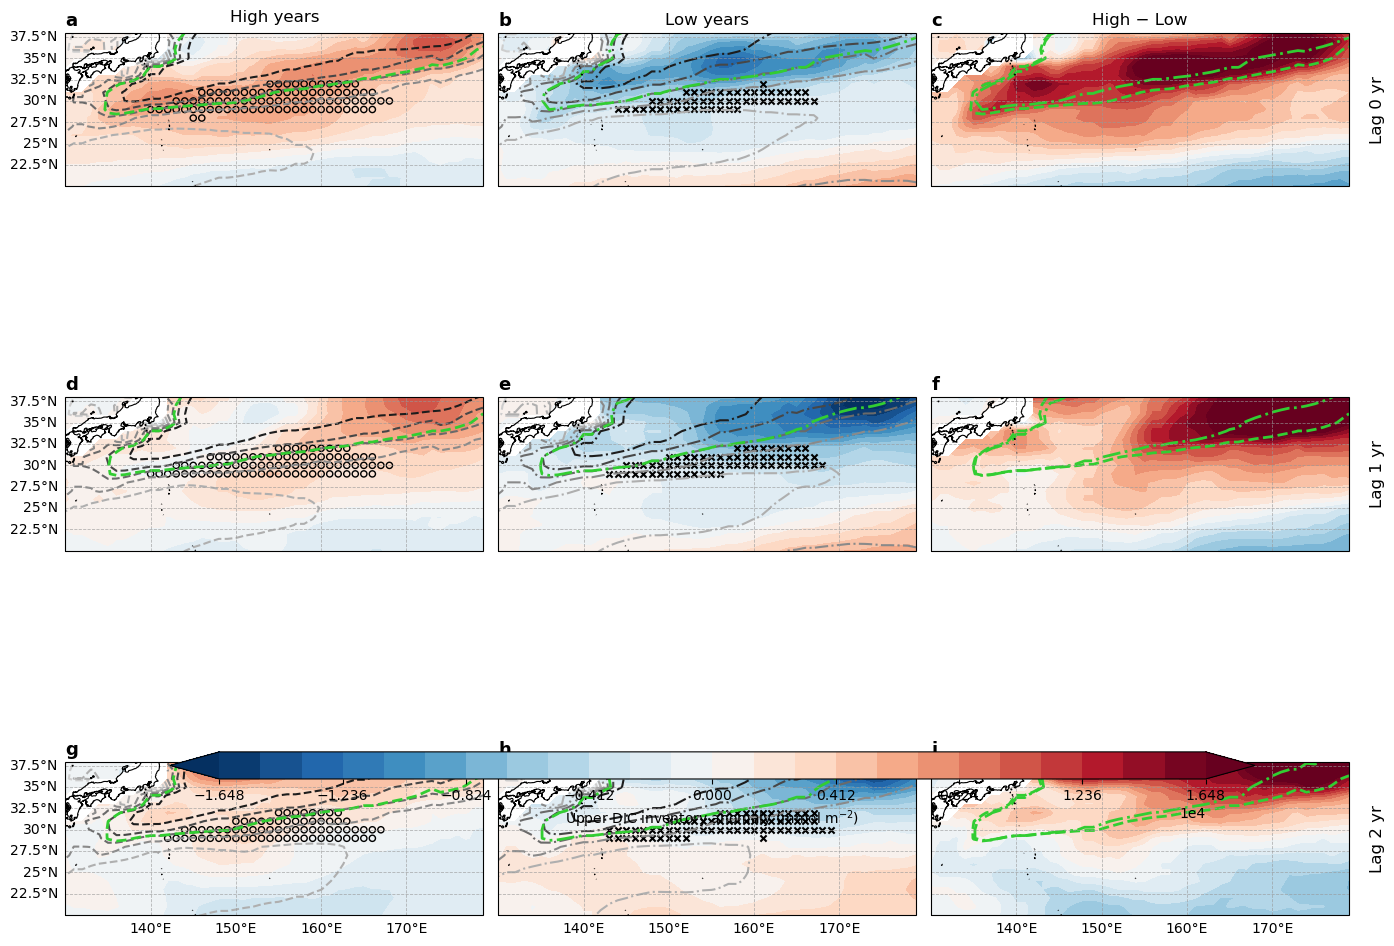

In [31]:
# ============================================================
# ODA Upper DIC inventory composites
# 3 rows = lag0 / lag1 / lag2
# 3 cols = High / Low / High−Low
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

MLD_LEVEL = 150
DEP_STMW = 200
EXTENT = [130, 179, 20, 38]
THRESH = 0.8

proj = ccrs.PlateCarree()

# ============================================================
# build lagged fields (ODA only)
# ============================================================

def build_lag_fields(lag):

    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    return build_fields(
        f"ODA_lag{lag}",
        results["DIC_INV"].ODA_upper,
        results["MLD"].ODA_ds_rgd,
        ODA_STMWW_rgd,
        high_lag, low_lag
    )

ODA_lag0 = build_lag_fields(0)
ODA_lag1 = build_lag_fields(1)
ODA_lag2 = build_lag_fields(2)

ODA_all = [ODA_lag0, ODA_lag1, ODA_lag2]

# ============================================================
# shared anomaly color scale
# ============================================================

all_fields = []
for D in ODA_all:
    all_fields += [D["dic_high"], D["dic_low"], D["dic_diff"]]

levels, vmax = robust_symmetric_levels(all_fields, q=98, nlev=25)
raw_colors = plt.cm.Greys(np.linspace(0.3, 0.9, 6))



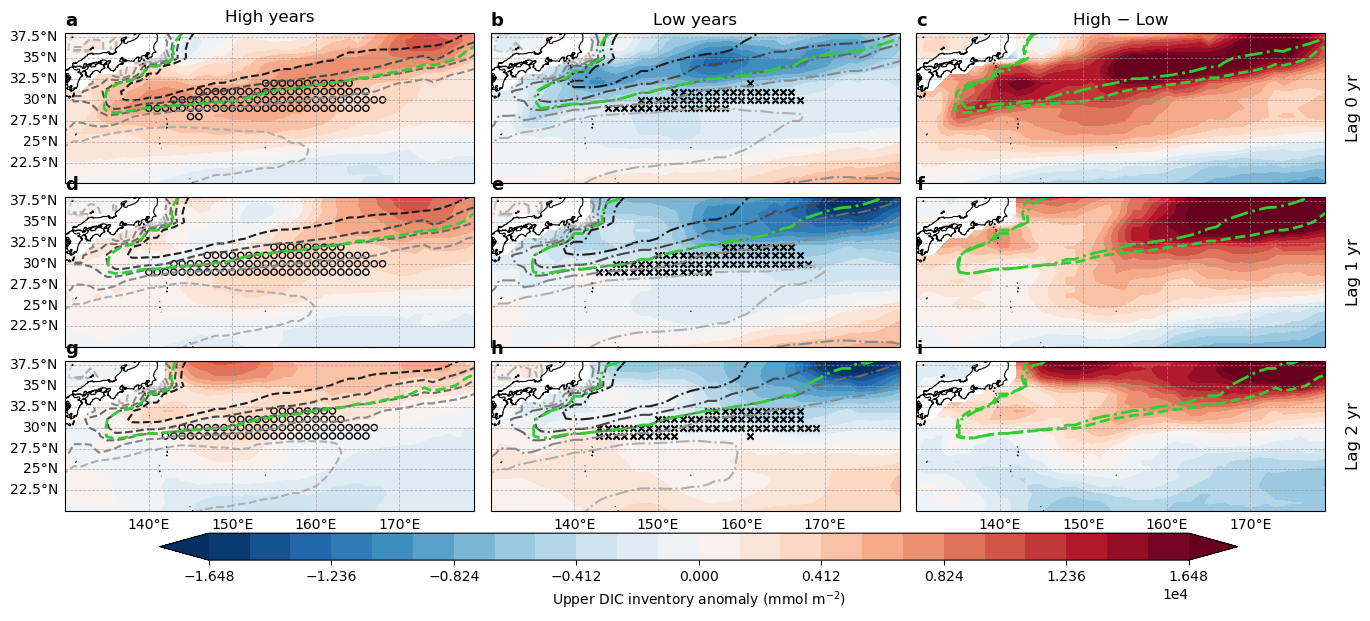

In [35]:
# ============================================================
# PLOT 3×3
# ============================================================

fig, axes = plt.subplots(
    3, 3,
    figsize=(14, 7),
    subplot_kw={"projection": proj},
    sharex=True, sharey=True
)

col_titles = ["High years", "Low years", "High − Low"]
row_titles = ["Lag 0 yr", "Lag 1 yr", "Lag 2 yr"]

panel_letter = ord("a")
CF = None

for r, D in enumerate(ODA_all):

    for c in range(3):

        ax = axes[r, c]

        if c == 0:
            f = D["dic_high"]
        elif c == 1:
            f = D["dic_low"]
        else:
            f = D["dic_diff"]

        lon, lat = get_lon_lat(f)

        CF = ax.contourf(
            lon, lat, f,
            levels=levels,
            cmap="RdBu_r",
            vmin=-vmax, vmax=vmax,
            extend="both",
            transform=proj,
            zorder=1
        )

        ax.set_extent(EXTENT, crs=proj)
        ax.coastlines(resolution="10m", linewidth=0.8, zorder=4)

        # grid
        gl = ax.gridlines(
            crs=proj, draw_labels=True,
            linewidth=0.6, color="0.6",
            linestyle="--", alpha=0.7
        )

        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (c == 0)
        gl.bottom_labels = (r == 2)

        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        # column titles
        if r == 0:
            ax.set_title(col_titles[c])

        # row titles
        if c == 2:
            ax.text(
                1.05, 0.5, row_titles[r],
                transform=ax.transAxes,
                rotation=90,
                va="center", ha="left",
                fontsize=12
            )

        # panel label
        ax.text(
            0, 1.02, chr(panel_letter),
            transform=ax.transAxes,
            fontsize=13, fontweight="bold",
            ha="left", va="bottom",
            clip_on=False
        )
        panel_letter += 1

        # overlays
        if c == 0:  # High
            ax.contour(lon, lat, D["dic_high_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="--",
                       transform=proj)
            ax.contour(lon, lat, D["MLD_high"], [MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.scatter(D["lon_h"], D["lat_h"],
                       s=20, facecolors="none",
                       edgecolors="k",
                       transform=proj)

        elif c == 1:  # Low
            ax.contour(lon, lat, D["dic_low_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="-.",
                       transform=proj)
            ax.contour(lon, lat, D["MLD_low"], [MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(D["lon_l"], D["lat_l"],
                       s=20, c="k", marker="x",
                       transform=proj)

        else:  # Diff
            ax.contour(lon, lat, D["MLD_high"], [MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.contour(lon, lat, D["MLD_low"], [MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)

# ============================================================
# shared colorbar
# ============================================================

cbar = fig.colorbar(
    CF, ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    aspect=40
)

cbar.set_label("Upper DIC inventory anomaly (mmol m$^{-2}$)")
cbar.formatter.set_powerlimits((-2, 2))
cbar.update_ticks()

fig.subplots_adjust(
    left=0.06,
    right=0.96,
    top=0.88,
    bottom=0.18,
    wspace=0.04,
    hspace=0.01,
)

# plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# BLOCK 1: BUILD & SAVE CACHE (ODA nDIC @300m, lag0–2)
# ============================================================

import numpy as np
import xarray as xr

DEP_LEVEL = 300
DEP_STMW  = 200
MLD_LEVEL = 150
THRESH = 0.8

CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC300_lag012_ODA.nc"

# ------------------------------------------------------------
# base field (load once)
# ------------------------------------------------------------
ndic = results["nDIC"].ODA_ds_rgd["nDIC"]

ens_dim = next((d for d in ndic.dims if d.startswith("ens")), None)
if ens_dim:
    ndic = ndic.mean(ens_dim)

ndic = ndic.sel(z_t=DEP_LEVEL*100, method="nearest")
ndic_ann = ndic.groupby("time.year").mean("time")

clim_mask = (ndic_ann.year >= 1990) & (ndic_ann.year <= 2020)
ndic_clim = ndic_ann.sel(year=clim_mask).mean("year").load()

# ------------------------------------------------------------
# MLD (FMA only, precompute once)
# ------------------------------------------------------------
MLD = results["MLD"].ODA_ds_rgd
MLD = MLD["MLD"] if isinstance(MLD, xr.Dataset) else MLD

ens_dim = next((d for d in MLD.dims if d.startswith("ens")), None)
if ens_dim:
    MLD = MLD.mean(ens_dim)

MLD = MLD.where(MLD.time.dt.month.isin([2,3,4]), drop=True) / 100.0
MLD_ann = MLD.groupby("time.year").mean("time")

# ------------------------------------------------------------
# BUILD DATASET
# ------------------------------------------------------------
ds_out = xr.Dataset()

for lag in [0,1,2]:

    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    ndic_high = ndic_ann.sel(year=np.isin(ndic_ann.year, high_lag)).mean("year")
    ndic_low  = ndic_ann.sel(year=np.isin(ndic_ann.year, low_lag)).mean("year")

    ndic_high_anom = (ndic_high - ndic_clim).load()
    ndic_low_anom  = (ndic_low  - ndic_clim).load()
    ndic_diff      = (ndic_high - ndic_low).load()

    mld_high = MLD_ann.sel(year=np.isin(MLD_ann.year, high_lag)).mean("year").load()
    mld_low  = MLD_ann.sel(year=np.isin(MLD_ann.year, low_lag)).mean("year").load()

    tag = f"lag{lag}"

    ds_out[f"ndic_high_{tag}"] = ndic_high
    ds_out[f"ndic_low_{tag}"]  = ndic_low
    ds_out[f"ndic_high_anom_{tag}"] = ndic_high_anom
    ds_out[f"ndic_low_anom_{tag}"]  = ndic_low_anom
    ds_out[f"ndic_diff_{tag}"]      = ndic_diff

    ds_out[f"mld_high_{tag}"] = mld_high
    ds_out[f"mld_low_{tag}"]  = mld_low

# save
ds_out.to_netcdf(CACHE_FILE)
print("Saved:", CACHE_FILE)

Saved: /mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC300_lag012_ODA.nc


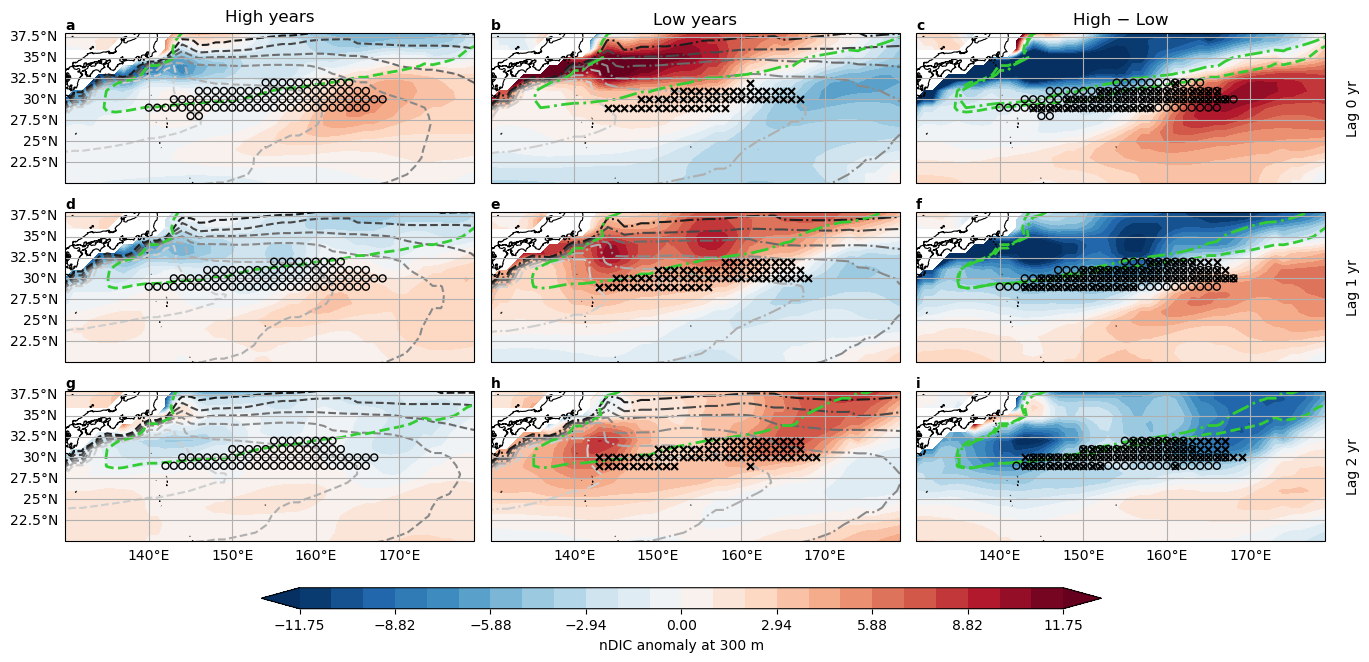

In [47]:
# ============================================================
# ODA nDIC @300m composites (lag0–2) from CACHE
# 3 rows = lag0 / lag1 / lag2
# 3 cols = High / Low / High−Low
# + STMW markers (High=o, Low=x)
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC300_lag012_ODA.nc"

high_sel = np.array([1991,1993,1994,1996,2003,2004,
                     2011,2012,2013,2014,2015])

low_sel  = np.array([1997,1998,1999,2000,2001,
                     2007,2008,2009,2010,2016])

DEP_STMW  = 200
MLD_LEVEL = 150
THRESH    = 0.8
EXTENT    = [130,179,20,38]

proj = ccrs.PlateCarree()

# ------------------------------------------------------------
# LOAD CACHE
# ------------------------------------------------------------
ds = xr.open_dataset(CACHE_FILE)

# ------------------------------------------------------------
# STMW MASK FUNCTION
# ------------------------------------------------------------
def build_stmw_mask(high_years, low_years):

    stmw = ODA_STMWW_rgd.sel(z_t=DEP_STMW*100, method="nearest")

    years_cf = np.array([t.year for t in stmw.time.values], dtype=int)
    year_coord = xr.DataArray(years_cf, dims="time")

    stmw_frac = (
        (stmw > 0)
        .groupby(year_coord)
        .mean("time")
        .rename({"group": "year"})
    )

    stmw_high = stmw_frac.sel(
        year=np.intersect1d(high_years, stmw_frac.year)
    ).mean("year") >= THRESH

    stmw_low = stmw_frac.sel(
        year=np.intersect1d(low_years, stmw_frac.year)
    ).mean("year") >= THRESH

    iy_h, ix_h = np.where(stmw_high.values)
    iy_l, ix_l = np.where(stmw_low.values)

    lon_h = stmw_high.lon.values[ix_h]
    lat_h = stmw_high.lat.values[iy_h]

    lon_l = stmw_low.lon.values[ix_l]
    lat_l = stmw_low.lat.values[iy_l]

    return lon_h, lat_h, lon_l, lat_l


# ------------------------------------------------------------
# BUILD ODA_all
# ------------------------------------------------------------
ODA_all = []

for lag in [0,1,2]:

    tag = f"lag{lag}"

    D = dict()

    D["dic_high"] = ds[f"ndic_high_anom_{tag}"]
    D["dic_low"]  = ds[f"ndic_low_anom_{tag}"]
    D["dic_diff"] = ds[f"ndic_diff_{tag}"]

    D["dic_high_raw"] = ds[f"ndic_high_{tag}"]
    D["dic_low_raw"]  = ds[f"ndic_low_{tag}"]

    D["MLD_high"] = ds[f"mld_high_{tag}"]
    D["MLD_low"]  = ds[f"mld_low_{tag}"]

    raw_vals = np.concatenate([
        D["dic_high_raw"].values[np.isfinite(D["dic_high_raw"].values)],
        D["dic_low_raw"].values[np.isfinite(D["dic_low_raw"].values)]
    ])

    D["raw_levels"] = np.linspace(
        np.nanpercentile(raw_vals, 10),
        np.nanpercentile(raw_vals, 90),
        6
    )

    ODA_all.append(D)

# ------------------------------------------------------------
# SHARED COLOR SCALE
# ------------------------------------------------------------
def robust_symmetric_levels(fields, q=98, nlev=25):
    vals = []
    for f in fields:
        v = f.values
        vals.append(v[np.isfinite(v)])
    vals = np.concatenate(vals)
    vmax = np.nanpercentile(np.abs(vals), q)
    levels = np.linspace(-vmax, vmax, nlev)
    return levels, vmax

all_fields = []
for D in ODA_all:
    all_fields += [D["dic_high"], D["dic_low"], D["dic_diff"]]

levels, vmax = robust_symmetric_levels(all_fields, q=98, nlev=25)
raw_colors = plt.cm.Greys(np.linspace(0.3,0.9,6))

# ------------------------------------------------------------
# PLOT 3×3
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3, 3,
    figsize=(14,7),
    subplot_kw={"projection": proj},
    sharex=True, sharey=True
)

col_titles = ["High years", "Low years", "High − Low"]
row_titles = ["Lag 0 yr", "Lag 1 yr", "Lag 2 yr"]

panel_letter = ord("a")
CF = None

for r, D in enumerate(ODA_all):

    lag = r
    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    lon_h, lat_h, lon_l, lat_l = build_stmw_mask(high_lag, low_lag)

    for c in range(3):

        ax = axes[r,c]

        if c == 0:
            f = D["dic_high"]
        elif c == 1:
            f = D["dic_low"]
        else:
            f = D["dic_diff"]

        lon = f.lon
        lat = f.lat

        CF = ax.contourf(
            lon, lat, f,
            levels=levels,
            cmap="RdBu_r",
            vmin=-vmax, vmax=vmax,
            extend="both",
            transform=proj,
            zorder=1
        )

        ax.set_extent(EXTENT, crs=proj)
        ax.coastlines(resolution="10m", linewidth=0.8)

        gl = ax.gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (c == 0)
        gl.bottom_labels = (r == 2)
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        if r == 0:
            ax.set_title(col_titles[c])

        if c == 2:
            ax.text(1.05,0.5,row_titles[r],
                    transform=ax.transAxes,
                    rotation=90,va="center")

        ax.text(0,1.02,chr(panel_letter),
                transform=ax.transAxes,
                fontweight="bold")

        panel_letter += 1

        # overlays
        if c == 0:
            ax.contour(lon,lat,D["dic_high_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="--",
                       transform=proj)
            ax.contour(lon,lat,D["MLD_high"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_h,lat_h,s=25,
                       facecolors="none",
                       edgecolors="k",
                       transform=proj,zorder=6)

        elif c == 1:
            ax.contour(lon,lat,D["dic_low_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="-.",
                       transform=proj)
            ax.contour(lon,lat,D["MLD_low"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_l,lat_l,s=25,
                       c="k",marker="x",
                       transform=proj,zorder=6)

        else:
            ax.contour(lon,lat,D["MLD_high"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.contour(lon,lat,D["MLD_low"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_h,lat_h,s=25,
                       facecolors="none",
                       edgecolors="k",
                       transform=proj,zorder=6)
            ax.scatter(lon_l,lat_l,s=25,
                       c="k",marker="x",
                       transform=proj,zorder=6)

# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------
cax = fig.add_axes([0.2,0.06,0.6,0.03])
cbar = fig.colorbar(CF,cax=cax,orientation="horizontal")
cbar.set_label("nDIC anomaly at 300 m")

fig.subplots_adjust(left=0.06,right=0.96,
                    top=0.9,bottom=0.14,
                    wspace=0.04,hspace=0.03)

plt.show()

In [48]:
# ============================================================
# BLOCK 1: BUILD & SAVE CACHE (WDA nDIC @300m, lag0–2)
# ============================================================

import numpy as np
import xarray as xr

DEP_LEVEL = 300
DEP_STMW  = 200
MLD_LEVEL = 150
THRESH = 0.8

CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC300_lag012_WDA.nc"

# ------------------------------------------------------------
# base field (load once)
# ------------------------------------------------------------
ndic = results["nDIC"].WDA_ds_rgd["nDIC"]

ens_dim = next((d for d in ndic.dims if d.startswith("ens")), None)
if ens_dim:
    ndic = ndic.mean(ens_dim)

ndic = ndic.sel(z_t=DEP_LEVEL*100, method="nearest")
ndic_ann = ndic.groupby("time.year").mean("time")

clim_mask = (ndic_ann.year >= 1990) & (ndic_ann.year <= 2020)
ndic_clim = ndic_ann.sel(year=clim_mask).mean("year").load()

# ------------------------------------------------------------
# MLD (FMA only, precompute once)
# ------------------------------------------------------------
MLD = results["MLD"].WDA_ds_rgd
MLD = MLD["MLD"] if isinstance(MLD, xr.Dataset) else MLD

ens_dim = next((d for d in MLD.dims if d.startswith("ens")), None)
if ens_dim:
    MLD = MLD.mean(ens_dim)

MLD = MLD.where(MLD.time.dt.month.isin([2,3,4]), drop=True) / 100.0
MLD_ann = MLD.groupby("time.year").mean("time")

# ------------------------------------------------------------
# BUILD DATASET
# ------------------------------------------------------------
ds_out = xr.Dataset()

for lag in [0,1,2]:

    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    ndic_high = ndic_ann.sel(year=np.isin(ndic_ann.year, high_lag)).mean("year")
    ndic_low  = ndic_ann.sel(year=np.isin(ndic_ann.year, low_lag)).mean("year")

    ndic_high_anom = (ndic_high - ndic_clim).load()
    ndic_low_anom  = (ndic_low  - ndic_clim).load()
    ndic_diff      = (ndic_high - ndic_low).load()

    mld_high = MLD_ann.sel(year=np.isin(MLD_ann.year, high_lag)).mean("year").load()
    mld_low  = MLD_ann.sel(year=np.isin(MLD_ann.year, low_lag)).mean("year").load()

    tag = f"lag{lag}"

    ds_out[f"ndic_high_{tag}"] = ndic_high
    ds_out[f"ndic_low_{tag}"]  = ndic_low
    ds_out[f"ndic_high_anom_{tag}"] = ndic_high_anom
    ds_out[f"ndic_low_anom_{tag}"]  = ndic_low_anom
    ds_out[f"ndic_diff_{tag}"]      = ndic_diff

    ds_out[f"mld_high_{tag}"] = mld_high
    ds_out[f"mld_low_{tag}"]  = mld_low

# save
ds_out.to_netcdf(CACHE_FILE)
print("Saved:", CACHE_FILE)

Saved: /mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC300_lag012_WDA.nc


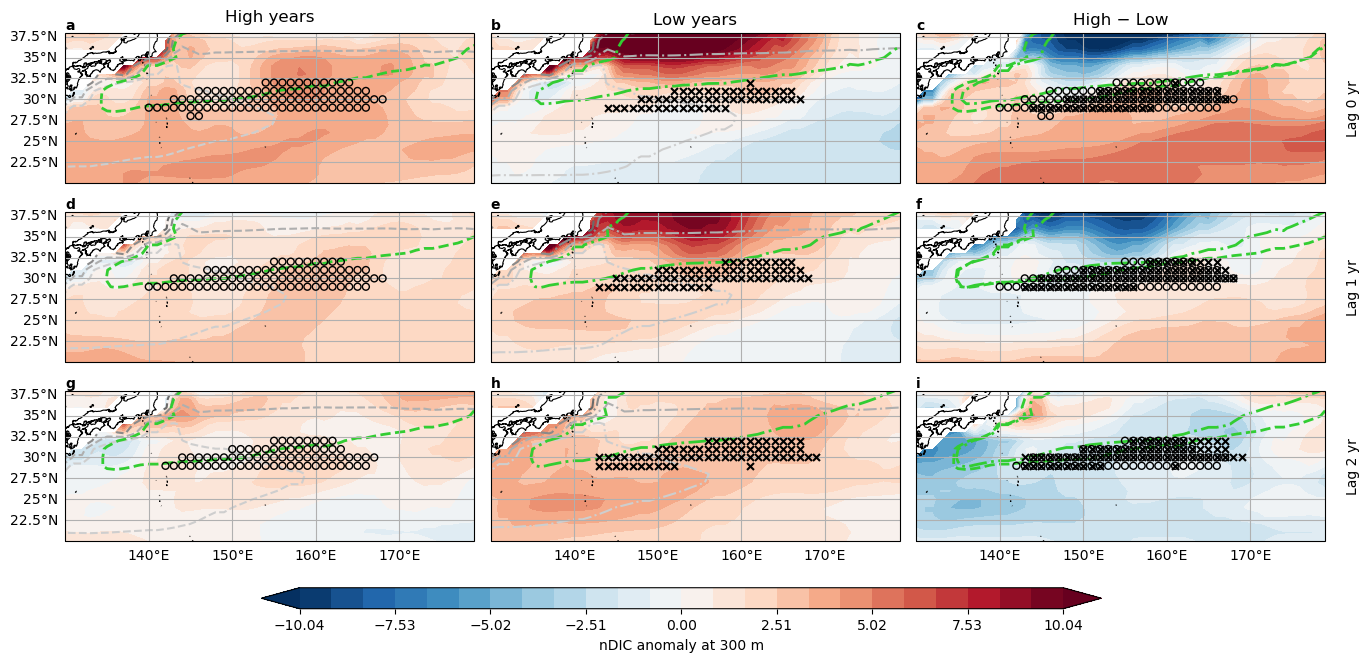

In [49]:
# ============================================================
# ODA nDIC @300m composites (lag0–2) from CACHE
# 3 rows = lag0 / lag1 / lag2
# 3 cols = High / Low / High−Low
# + STMW markers (High=o, Low=x)
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC300_lag012_WDA.nc"

high_sel = np.array([1991,1993,1994,1996,2003,2004,
                     2011,2012,2013,2014,2015])

low_sel  = np.array([1997,1998,1999,2000,2001,
                     2007,2008,2009,2010,2016])

DEP_STMW  = 200
MLD_LEVEL = 150
THRESH    = 0.8
EXTENT    = [130,179,20,38]

proj = ccrs.PlateCarree()

# ------------------------------------------------------------
# LOAD CACHE
# ------------------------------------------------------------
ds = xr.open_dataset(CACHE_FILE)

# ------------------------------------------------------------
# STMW MASK FUNCTION
# ------------------------------------------------------------
def build_stmw_mask(high_years, low_years):

    stmw = ODA_STMWW_rgd.sel(z_t=DEP_STMW*100, method="nearest")

    years_cf = np.array([t.year for t in stmw.time.values], dtype=int)
    year_coord = xr.DataArray(years_cf, dims="time")

    stmw_frac = (
        (stmw > 0)
        .groupby(year_coord)
        .mean("time")
        .rename({"group": "year"})
    )

    stmw_high = stmw_frac.sel(
        year=np.intersect1d(high_years, stmw_frac.year)
    ).mean("year") >= THRESH

    stmw_low = stmw_frac.sel(
        year=np.intersect1d(low_years, stmw_frac.year)
    ).mean("year") >= THRESH

    iy_h, ix_h = np.where(stmw_high.values)
    iy_l, ix_l = np.where(stmw_low.values)

    lon_h = stmw_high.lon.values[ix_h]
    lat_h = stmw_high.lat.values[iy_h]

    lon_l = stmw_low.lon.values[ix_l]
    lat_l = stmw_low.lat.values[iy_l]

    return lon_h, lat_h, lon_l, lat_l


# ------------------------------------------------------------
# BUILD ODA_all
# ------------------------------------------------------------
ODA_all = []

for lag in [0,1,2]:

    tag = f"lag{lag}"

    D = dict()

    D["dic_high"] = ds[f"ndic_high_anom_{tag}"]
    D["dic_low"]  = ds[f"ndic_low_anom_{tag}"]
    D["dic_diff"] = ds[f"ndic_diff_{tag}"]

    D["dic_high_raw"] = ds[f"ndic_high_{tag}"]
    D["dic_low_raw"]  = ds[f"ndic_low_{tag}"]

    D["MLD_high"] = ds[f"mld_high_{tag}"]
    D["MLD_low"]  = ds[f"mld_low_{tag}"]

    raw_vals = np.concatenate([
        D["dic_high_raw"].values[np.isfinite(D["dic_high_raw"].values)],
        D["dic_low_raw"].values[np.isfinite(D["dic_low_raw"].values)]
    ])

    D["raw_levels"] = np.linspace(
        np.nanpercentile(raw_vals, 10),
        np.nanpercentile(raw_vals, 90),
        6
    )

    ODA_all.append(D)

# ------------------------------------------------------------
# SHARED COLOR SCALE
# ------------------------------------------------------------
def robust_symmetric_levels(fields, q=98, nlev=25):
    vals = []
    for f in fields:
        v = f.values
        vals.append(v[np.isfinite(v)])
    vals = np.concatenate(vals)
    vmax = np.nanpercentile(np.abs(vals), q)
    levels = np.linspace(-vmax, vmax, nlev)
    return levels, vmax

all_fields = []
for D in ODA_all:
    all_fields += [D["dic_high"], D["dic_low"], D["dic_diff"]]

levels, vmax = robust_symmetric_levels(all_fields, q=98, nlev=25)
raw_colors = plt.cm.Greys(np.linspace(0.3,0.9,6))

# ------------------------------------------------------------
# PLOT 3×3
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3, 3,
    figsize=(14,7),
    subplot_kw={"projection": proj},
    sharex=True, sharey=True
)

col_titles = ["High years", "Low years", "High − Low"]
row_titles = ["Lag 0 yr", "Lag 1 yr", "Lag 2 yr"]

panel_letter = ord("a")
CF = None

for r, D in enumerate(ODA_all):

    lag = r
    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    lon_h, lat_h, lon_l, lat_l = build_stmw_mask(high_lag, low_lag)

    for c in range(3):

        ax = axes[r,c]

        if c == 0:
            f = D["dic_high"]
        elif c == 1:
            f = D["dic_low"]
        else:
            f = D["dic_diff"]

        lon = f.lon
        lat = f.lat

        CF = ax.contourf(
            lon, lat, f,
            levels=levels,
            cmap="RdBu_r",
            vmin=-vmax, vmax=vmax,
            extend="both",
            transform=proj,
            zorder=1
        )

        ax.set_extent(EXTENT, crs=proj)
        ax.coastlines(resolution="10m", linewidth=0.8)

        gl = ax.gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (c == 0)
        gl.bottom_labels = (r == 2)
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        if r == 0:
            ax.set_title(col_titles[c])

        if c == 2:
            ax.text(1.05,0.5,row_titles[r],
                    transform=ax.transAxes,
                    rotation=90,va="center")

        ax.text(0,1.02,chr(panel_letter),
                transform=ax.transAxes,
                fontweight="bold")

        panel_letter += 1

        # overlays
        if c == 0:
            ax.contour(lon,lat,D["dic_high_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="--",
                       transform=proj)
            ax.contour(lon,lat,D["MLD_high"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_h,lat_h,s=25,
                       facecolors="none",
                       edgecolors="k",
                       transform=proj,zorder=6)

        elif c == 1:
            ax.contour(lon,lat,D["dic_low_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="-.",
                       transform=proj)
            ax.contour(lon,lat,D["MLD_low"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_l,lat_l,s=25,
                       c="k",marker="x",
                       transform=proj,zorder=6)

        else:
            ax.contour(lon,lat,D["MLD_high"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.contour(lon,lat,D["MLD_low"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_h,lat_h,s=25,
                       facecolors="none",
                       edgecolors="k",
                       transform=proj,zorder=6)
            ax.scatter(lon_l,lat_l,s=25,
                       c="k",marker="x",
                       transform=proj,zorder=6)

# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------
cax = fig.add_axes([0.2,0.06,0.6,0.03])
cbar = fig.colorbar(CF,cax=cax,orientation="horizontal")
cbar.set_label("nDIC anomaly at 300 m")

fig.subplots_adjust(left=0.06,right=0.96,
                    top=0.9,bottom=0.14,
                    wspace=0.04,hspace=0.03)

plt.show()

In [52]:
# ============================================================
# BUILD & SAVE CACHE (ODA nDIC 100–250m thickness-weighted)
# ============================================================

import numpy as np
import xarray as xr

DEP_MIN = 100   # m
DEP_MAX = 250   # m
DEP_STMW  = 200
MLD_LEVEL = 150
THRESH = 0.8

CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC100_250_lag012_ODA.nc"

# ------------------------------------------------------------
# Load nDIC
# ------------------------------------------------------------
ndic = results["nDIC"].ODA_ds_rgd["nDIC"]

ens_dim = next((d for d in ndic.dims if d.startswith("ens")), None)
if ens_dim:
    ndic = ndic.mean(ens_dim)

# convert z_t to meters
z_m = ndic.z_t / 100.0

# select depth range
ndic = ndic.where((z_m >= DEP_MIN) & (z_m <= DEP_MAX), drop=True)

# ------------------------------------------------------------
# Thickness weighting (SAFE VERSION)
# ------------------------------------------------------------
dz = ds_grid.dz

# interpolate to match ndic vertical coordinate
dz = dz.interp(z_t=ndic.z_t)

weights = dz / dz.sum("z_t")

ndic_weighted = (ndic * weights).sum("z_t")

# ------------------------------------------------------------
# Annual mean
# ------------------------------------------------------------
ndic_ann = ndic_weighted.groupby("time.year").mean("time")

clim_mask = (ndic_ann.year >= 1990) & (ndic_ann.year <= 2020)
ndic_clim = ndic_ann.sel(year=clim_mask).mean("year").load()

# ------------------------------------------------------------
# MLD (FMA)
# ------------------------------------------------------------
MLD = results["MLD"].ODA_ds_rgd
MLD = MLD["MLD"] if isinstance(MLD, xr.Dataset) else MLD

ens_dim = next((d for d in MLD.dims if d.startswith("ens")), None)
if ens_dim:
    MLD = MLD.mean(ens_dim)

MLD = MLD.where(MLD.time.dt.month.isin([2,3,4]), drop=True) / 100.0
MLD_ann = MLD.groupby("time.year").mean("time")

# ------------------------------------------------------------
# BUILD DATASET
# ------------------------------------------------------------
ds_out = xr.Dataset()

for lag in [0,1,2]:

    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    ndic_high = ndic_ann.sel(year=np.isin(ndic_ann.year, high_lag)).mean("year")
    ndic_low  = ndic_ann.sel(year=np.isin(ndic_ann.year, low_lag)).mean("year")

    ndic_high_anom = (ndic_high - ndic_clim).load()
    ndic_low_anom  = (ndic_low  - ndic_clim).load()
    ndic_diff      = (ndic_high - ndic_low).load()

    mld_high = MLD_ann.sel(year=np.isin(MLD_ann.year, high_lag)).mean("year").load()
    mld_low  = MLD_ann.sel(year=np.isin(MLD_ann.year, low_lag)).mean("year").load()

    tag = f"lag{lag}"

    ds_out[f"ndic_high_{tag}"] = ndic_high
    ds_out[f"ndic_low_{tag}"]  = ndic_low
    ds_out[f"ndic_high_anom_{tag}"] = ndic_high_anom
    ds_out[f"ndic_low_anom_{tag}"]  = ndic_low_anom
    ds_out[f"ndic_diff_{tag}"]      = ndic_diff

    ds_out[f"mld_high_{tag}"] = mld_high
    ds_out[f"mld_low_{tag}"]  = mld_low

# save
ds_out.to_netcdf(CACHE_FILE)
print("Saved:", CACHE_FILE)

Saved: /mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC100_250_lag012_ODA.nc


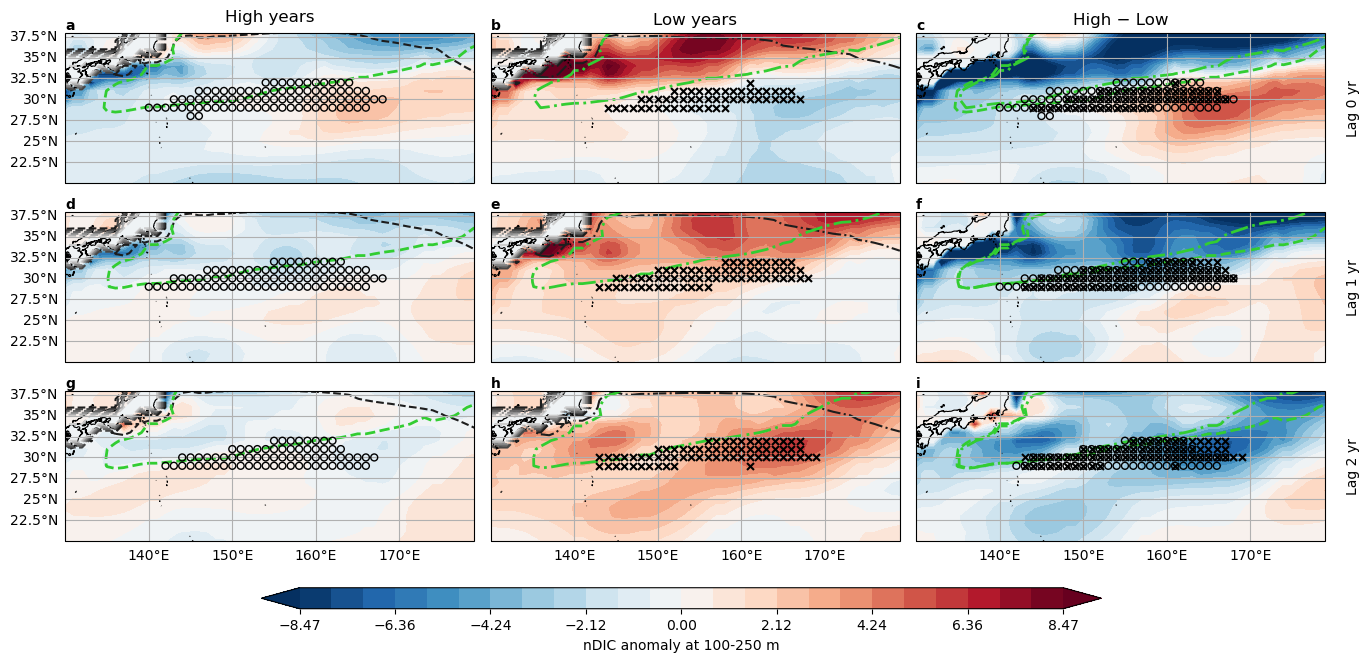

In [54]:
# ============================================================
# ODA nDIC @300m composites (lag0–2) from CACHE
# 3 rows = lag0 / lag1 / lag2
# 3 cols = High / Low / High−Low
# + STMW markers (High=o, Low=x)
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC100_250_lag012_ODA.nc"

high_sel = np.array([1991,1993,1994,1996,2003,2004,
                     2011,2012,2013,2014,2015])

low_sel  = np.array([1997,1998,1999,2000,2001,
                     2007,2008,2009,2010,2016])

DEP_STMW  = 200
MLD_LEVEL = 150
THRESH    = 0.8
EXTENT    = [130,179,20,38]

proj = ccrs.PlateCarree()

# ------------------------------------------------------------
# LOAD CACHE
# ------------------------------------------------------------
ds = xr.open_dataset(CACHE_FILE)

# ------------------------------------------------------------
# STMW MASK FUNCTION
# ------------------------------------------------------------
def build_stmw_mask(high_years, low_years):

    stmw = ODA_STMWW_rgd.sel(z_t=DEP_STMW*100, method="nearest")

    years_cf = np.array([t.year for t in stmw.time.values], dtype=int)
    year_coord = xr.DataArray(years_cf, dims="time")

    stmw_frac = (
        (stmw > 0)
        .groupby(year_coord)
        .mean("time")
        .rename({"group": "year"})
    )

    stmw_high = stmw_frac.sel(
        year=np.intersect1d(high_years, stmw_frac.year)
    ).mean("year") >= THRESH

    stmw_low = stmw_frac.sel(
        year=np.intersect1d(low_years, stmw_frac.year)
    ).mean("year") >= THRESH

    iy_h, ix_h = np.where(stmw_high.values)
    iy_l, ix_l = np.where(stmw_low.values)

    lon_h = stmw_high.lon.values[ix_h]
    lat_h = stmw_high.lat.values[iy_h]

    lon_l = stmw_low.lon.values[ix_l]
    lat_l = stmw_low.lat.values[iy_l]

    return lon_h, lat_h, lon_l, lat_l


# ------------------------------------------------------------
# BUILD ODA_all
# ------------------------------------------------------------
ODA_all = []

for lag in [0,1,2]:

    tag = f"lag{lag}"

    D = dict()

    D["dic_high"] = ds[f"ndic_high_anom_{tag}"]
    D["dic_low"]  = ds[f"ndic_low_anom_{tag}"]
    D["dic_diff"] = ds[f"ndic_diff_{tag}"]

    D["dic_high_raw"] = ds[f"ndic_high_{tag}"]
    D["dic_low_raw"]  = ds[f"ndic_low_{tag}"]

    D["MLD_high"] = ds[f"mld_high_{tag}"]
    D["MLD_low"]  = ds[f"mld_low_{tag}"]

    raw_vals = np.concatenate([
        D["dic_high_raw"].values[np.isfinite(D["dic_high_raw"].values)],
        D["dic_low_raw"].values[np.isfinite(D["dic_low_raw"].values)]
    ])

    D["raw_levels"] = np.linspace(
        np.nanpercentile(raw_vals, 10),
        np.nanpercentile(raw_vals, 90),
        6
    )

    ODA_all.append(D)

# ------------------------------------------------------------
# SHARED COLOR SCALE
# ------------------------------------------------------------
def robust_symmetric_levels(fields, q=98, nlev=25):
    vals = []
    for f in fields:
        v = f.values
        vals.append(v[np.isfinite(v)])
    vals = np.concatenate(vals)
    vmax = np.nanpercentile(np.abs(vals), q)
    levels = np.linspace(-vmax, vmax, nlev)
    return levels, vmax

all_fields = []
for D in ODA_all:
    all_fields += [D["dic_high"], D["dic_low"], D["dic_diff"]]

levels, vmax = robust_symmetric_levels(all_fields, q=98, nlev=25)
raw_colors = plt.cm.Greys(np.linspace(0.3,0.9,6))

# ------------------------------------------------------------
# PLOT 3×3
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3, 3,
    figsize=(14,7),
    subplot_kw={"projection": proj},
    sharex=True, sharey=True
)

col_titles = ["High years", "Low years", "High − Low"]
row_titles = ["Lag 0 yr", "Lag 1 yr", "Lag 2 yr"]

panel_letter = ord("a")
CF = None

for r, D in enumerate(ODA_all):

    lag = r
    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    lon_h, lat_h, lon_l, lat_l = build_stmw_mask(high_lag, low_lag)

    for c in range(3):

        ax = axes[r,c]

        if c == 0:
            f = D["dic_high"]
        elif c == 1:
            f = D["dic_low"]
        else:
            f = D["dic_diff"]

        lon = f.lon
        lat = f.lat

        CF = ax.contourf(
            lon, lat, f,
            levels=levels,
            cmap="RdBu_r",
            vmin=-vmax, vmax=vmax,
            extend="both",
            transform=proj,
            zorder=1
        )

        ax.set_extent(EXTENT, crs=proj)
        ax.coastlines(resolution="10m", linewidth=0.8)

        gl = ax.gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (c == 0)
        gl.bottom_labels = (r == 2)
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        if r == 0:
            ax.set_title(col_titles[c])

        if c == 2:
            ax.text(1.05,0.5,row_titles[r],
                    transform=ax.transAxes,
                    rotation=90,va="center")

        ax.text(0,1.02,chr(panel_letter),
                transform=ax.transAxes,
                fontweight="bold")

        panel_letter += 1

        # overlays
        if c == 0:
            ax.contour(lon,lat,D["dic_high_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="--",
                       transform=proj)
            ax.contour(lon,lat,D["MLD_high"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_h,lat_h,s=25,
                       facecolors="none",
                       edgecolors="k",
                       transform=proj,zorder=6)

        elif c == 1:
            ax.contour(lon,lat,D["dic_low_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="-.",
                       transform=proj)
            ax.contour(lon,lat,D["MLD_low"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_l,lat_l,s=25,
                       c="k",marker="x",
                       transform=proj,zorder=6)

        else:
            ax.contour(lon,lat,D["MLD_high"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.contour(lon,lat,D["MLD_low"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_h,lat_h,s=25,
                       facecolors="none",
                       edgecolors="k",
                       transform=proj,zorder=6)
            ax.scatter(lon_l,lat_l,s=25,
                       c="k",marker="x",
                       transform=proj,zorder=6)

# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------
cax = fig.add_axes([0.2,0.06,0.6,0.03])
cbar = fig.colorbar(CF,cax=cax,orientation="horizontal")
cbar.set_label("nDIC anomaly at 100-250 m")

fig.subplots_adjust(left=0.06,right=0.96,
                    top=0.9,bottom=0.14,
                    wspace=0.04,hspace=0.03)

plt.show()

In [55]:
# ============================================================
# BUILD & SAVE CACHE (WDA nDIC 100–250m thickness-weighted)
# ============================================================

import numpy as np
import xarray as xr

DEP_MIN = 100   # m
DEP_MAX = 250   # m
DEP_STMW  = 200
MLD_LEVEL = 150
THRESH = 0.8

CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC100_250_lag012_WDA.nc"

# ------------------------------------------------------------
# Load nDIC (WDA)
# ------------------------------------------------------------
ndic = results["nDIC"].WDA_ds_rgd["nDIC"]

ens_dim = next((d for d in ndic.dims if d.startswith("ens")), None)
if ens_dim:
    ndic = ndic.mean(ens_dim)

# convert z_t to meters
z_m = ndic.z_t / 100.0

# select depth range
ndic = ndic.where((z_m >= DEP_MIN) & (z_m <= DEP_MAX), drop=True)

# ------------------------------------------------------------
# Thickness weighting (SAFE VERSION)
# ------------------------------------------------------------
dz = ds_grid.dz

# interpolate to match ndic vertical coordinate
dz = dz.interp(z_t=ndic.z_t)

weights = dz / dz.sum("z_t")

ndic_weighted = (ndic * weights).sum("z_t")

# ------------------------------------------------------------
# Annual mean
# ------------------------------------------------------------
ndic_ann = ndic_weighted.groupby("time.year").mean("time")

clim_mask = (ndic_ann.year >= 1990) & (ndic_ann.year <= 2020)
ndic_clim = ndic_ann.sel(year=clim_mask).mean("year").load()

# ------------------------------------------------------------
# MLD (FMA only)
# ------------------------------------------------------------
MLD = results["MLD"].WDA_ds_rgd
MLD = MLD["MLD"] if isinstance(MLD, xr.Dataset) else MLD

ens_dim = next((d for d in MLD.dims if d.startswith("ens")), None)
if ens_dim:
    MLD = MLD.mean(ens_dim)

MLD = MLD.where(MLD.time.dt.month.isin([2,3,4]), drop=True) / 100.0
MLD_ann = MLD.groupby("time.year").mean("time")

# ------------------------------------------------------------
# BUILD DATASET
# ------------------------------------------------------------
ds_out = xr.Dataset()

for lag in [0,1,2]:

    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    ndic_high = ndic_ann.sel(year=np.isin(ndic_ann.year, high_lag)).mean("year")
    ndic_low  = ndic_ann.sel(year=np.isin(ndic_ann.year, low_lag)).mean("year")

    ndic_high_anom = (ndic_high - ndic_clim).load()
    ndic_low_anom  = (ndic_low  - ndic_clim).load()
    ndic_diff      = (ndic_high - ndic_low).load()

    mld_high = MLD_ann.sel(year=np.isin(MLD_ann.year, high_lag)).mean("year").load()
    mld_low  = MLD_ann.sel(year=np.isin(MLD_ann.year, low_lag)).mean("year").load()

    tag = f"lag{lag}"

    ds_out[f"ndic_high_{tag}"] = ndic_high
    ds_out[f"ndic_low_{tag}"]  = ndic_low
    ds_out[f"ndic_high_anom_{tag}"] = ndic_high_anom
    ds_out[f"ndic_low_anom_{tag}"]  = ndic_low_anom
    ds_out[f"ndic_diff_{tag}"]      = ndic_diff

    ds_out[f"mld_high_{tag}"] = mld_high
    ds_out[f"mld_low_{tag}"]  = mld_low

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
ds_out.to_netcdf(CACHE_FILE)
print("Saved:", CACHE_FILE)

Saved: /mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC100_250_lag012_WDA.nc


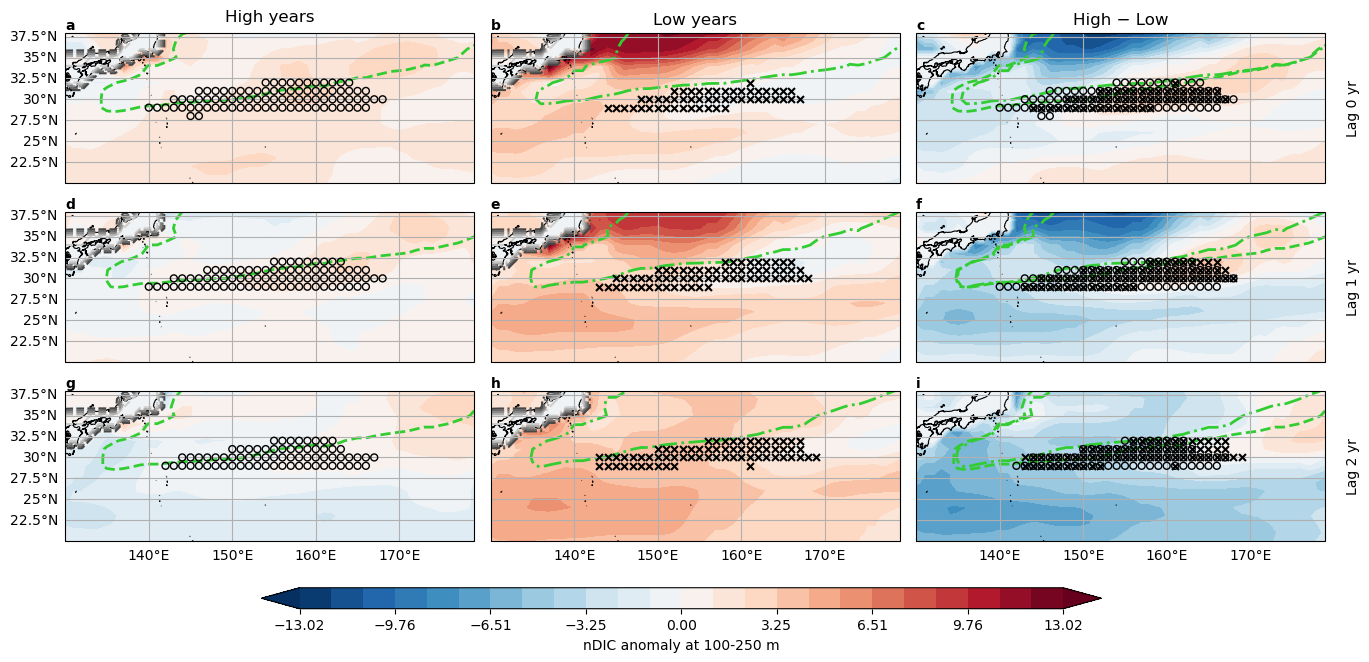

In [56]:
# ============================================================
# ODA nDIC @300m composites (lag0–2) from CACHE
# 3 rows = lag0 / lag1 / lag2
# 3 cols = High / Low / High−Low
# + STMW markers (High=o, Low=x)
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_nDIC100_250_lag012_WDA.nc"

high_sel = np.array([1991,1993,1994,1996,2003,2004,
                     2011,2012,2013,2014,2015])

low_sel  = np.array([1997,1998,1999,2000,2001,
                     2007,2008,2009,2010,2016])

DEP_STMW  = 200
MLD_LEVEL = 150
THRESH    = 0.8
EXTENT    = [130,179,20,38]

proj = ccrs.PlateCarree()

# ------------------------------------------------------------
# LOAD CACHE
# ------------------------------------------------------------
ds = xr.open_dataset(CACHE_FILE)

# ------------------------------------------------------------
# STMW MASK FUNCTION
# ------------------------------------------------------------
def build_stmw_mask(high_years, low_years):

    stmw = ODA_STMWW_rgd.sel(z_t=DEP_STMW*100, method="nearest")

    years_cf = np.array([t.year for t in stmw.time.values], dtype=int)
    year_coord = xr.DataArray(years_cf, dims="time")

    stmw_frac = (
        (stmw > 0)
        .groupby(year_coord)
        .mean("time")
        .rename({"group": "year"})
    )

    stmw_high = stmw_frac.sel(
        year=np.intersect1d(high_years, stmw_frac.year)
    ).mean("year") >= THRESH

    stmw_low = stmw_frac.sel(
        year=np.intersect1d(low_years, stmw_frac.year)
    ).mean("year") >= THRESH

    iy_h, ix_h = np.where(stmw_high.values)
    iy_l, ix_l = np.where(stmw_low.values)

    lon_h = stmw_high.lon.values[ix_h]
    lat_h = stmw_high.lat.values[iy_h]

    lon_l = stmw_low.lon.values[ix_l]
    lat_l = stmw_low.lat.values[iy_l]

    return lon_h, lat_h, lon_l, lat_l


# ------------------------------------------------------------
# BUILD ODA_all
# ------------------------------------------------------------
ODA_all = []

for lag in [0,1,2]:

    tag = f"lag{lag}"

    D = dict()

    D["dic_high"] = ds[f"ndic_high_anom_{tag}"]
    D["dic_low"]  = ds[f"ndic_low_anom_{tag}"]
    D["dic_diff"] = ds[f"ndic_diff_{tag}"]

    D["dic_high_raw"] = ds[f"ndic_high_{tag}"]
    D["dic_low_raw"]  = ds[f"ndic_low_{tag}"]

    D["MLD_high"] = ds[f"mld_high_{tag}"]
    D["MLD_low"]  = ds[f"mld_low_{tag}"]

    raw_vals = np.concatenate([
        D["dic_high_raw"].values[np.isfinite(D["dic_high_raw"].values)],
        D["dic_low_raw"].values[np.isfinite(D["dic_low_raw"].values)]
    ])

    D["raw_levels"] = np.linspace(
        np.nanpercentile(raw_vals, 10),
        np.nanpercentile(raw_vals, 90),
        6
    )

    ODA_all.append(D)

# ------------------------------------------------------------
# SHARED COLOR SCALE
# ------------------------------------------------------------
def robust_symmetric_levels(fields, q=98, nlev=25):
    vals = []
    for f in fields:
        v = f.values
        vals.append(v[np.isfinite(v)])
    vals = np.concatenate(vals)
    vmax = np.nanpercentile(np.abs(vals), q)
    levels = np.linspace(-vmax, vmax, nlev)
    return levels, vmax

all_fields = []
for D in ODA_all:
    all_fields += [D["dic_high"], D["dic_low"], D["dic_diff"]]

levels, vmax = robust_symmetric_levels(all_fields, q=98, nlev=25)
raw_colors = plt.cm.Greys(np.linspace(0.3,0.9,6))

# ------------------------------------------------------------
# PLOT 3×3
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3, 3,
    figsize=(14,7),
    subplot_kw={"projection": proj},
    sharex=True, sharey=True
)

col_titles = ["High years", "Low years", "High − Low"]
row_titles = ["Lag 0 yr", "Lag 1 yr", "Lag 2 yr"]

panel_letter = ord("a")
CF = None

for r, D in enumerate(ODA_all):

    lag = r
    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    lon_h, lat_h, lon_l, lat_l = build_stmw_mask(high_lag, low_lag)

    for c in range(3):

        ax = axes[r,c]

        if c == 0:
            f = D["dic_high"]
        elif c == 1:
            f = D["dic_low"]
        else:
            f = D["dic_diff"]

        lon = f.lon
        lat = f.lat

        CF = ax.contourf(
            lon, lat, f,
            levels=levels,
            cmap="RdBu_r",
            vmin=-vmax, vmax=vmax,
            extend="both",
            transform=proj,
            zorder=1
        )

        ax.set_extent(EXTENT, crs=proj)
        ax.coastlines(resolution="10m", linewidth=0.8)

        gl = ax.gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (c == 0)
        gl.bottom_labels = (r == 2)
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        if r == 0:
            ax.set_title(col_titles[c])

        if c == 2:
            ax.text(1.05,0.5,row_titles[r],
                    transform=ax.transAxes,
                    rotation=90,va="center")

        ax.text(0,1.02,chr(panel_letter),
                transform=ax.transAxes,
                fontweight="bold")

        panel_letter += 1

        # overlays
        if c == 0:
            ax.contour(lon,lat,D["dic_high_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="--",
                       transform=proj)
            ax.contour(lon,lat,D["MLD_high"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_h,lat_h,s=25,
                       facecolors="none",
                       edgecolors="k",
                       transform=proj,zorder=6)

        elif c == 1:
            ax.contour(lon,lat,D["dic_low_raw"],
                       levels=D["raw_levels"],
                       colors=raw_colors,
                       linestyles="-.",
                       transform=proj)
            ax.contour(lon,lat,D["MLD_low"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_l,lat_l,s=25,
                       c="k",marker="x",
                       transform=proj,zorder=6)

        else:
            ax.contour(lon,lat,D["MLD_high"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="--",
                       linewidths=2,
                       transform=proj)
            ax.contour(lon,lat,D["MLD_low"],[MLD_LEVEL],
                       colors="limegreen",
                       linestyles="-.",
                       linewidths=2,
                       transform=proj)
            ax.scatter(lon_h,lat_h,s=25,
                       facecolors="none",
                       edgecolors="k",
                       transform=proj,zorder=6)
            ax.scatter(lon_l,lat_l,s=25,
                       c="k",marker="x",
                       transform=proj,zorder=6)

# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------
cax = fig.add_axes([0.2,0.06,0.6,0.03])
cbar = fig.colorbar(CF,cax=cax,orientation="horizontal")
cbar.set_label("nDIC anomaly at 100-250 m")

fig.subplots_adjust(left=0.06,right=0.96,
                    top=0.9,bottom=0.14,
                    wspace=0.04,hspace=0.03)

plt.show()